# NLP and Baseline Modeling - Triagegeist - MIMIC-IV-ED - FULL DATASET

from https://physionet.org/content/mimic-iv-ed-demo/2.2/

metadata available at https://mimic.mit.edu/docs/iv/modules/ed/

## Index

- [1. Imports and Config](#1-imports-and-config)
- [2. Data Load (BigQuery)](#2-data-load-bigquery)
- [3. Chief Complaint NLP](#3-chief-complaint-nlp)
- [3.1 Text Cleaning](#31-text-cleaning)
- [3.2 Abbreviation Expansion](#32-abbreviation-expansion)
- [4. Semantic Clustering](#4-semantic-clustering)
- [5. Feature Engineering](#5-feature-engineering)
- [6. XGBoost (5 Classes)](#6-xgboost-5-classes)
- [7. XGBoost (4 Classes)](#7-xgboost-4-classes)
- [8. Optuna Tuning](#8-optuna-tuning)
- [9. LightGBM Benchmark](#9-lightgbm-benchmark)
- [10. GroupKFold Cross-Validation](#10-groupkfold-cross-validation)
- [11. SHAP Explainability](#11-shap-explainability)
- [12. Ensemble (XGBoost + LightGBM)](#12-ensemble-xgboost--lightgbm)

## 1. Imports and Config

In [ ]:
# Run once if needed
# %pip install pandas numpy seaborn matplotlib scikit-learn scipy google-cloud-bigquery db-dtypes sentence-transformers xgboost lightgbm optuna shap

In [10]:
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import xgboost as xgb
import lightgbm as lgb

from google.api_core.exceptions import Forbidden
from google.auth.exceptions import DefaultCredentialsError
from google.cloud import bigquery
from google.oauth2 import service_account

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer, normalize

SEED = 42
SUPPRESS_PACKAGE_WARNINGS = True
if SUPPRESS_PACKAGE_WARNINGS:
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# BigQuery config
BQ_BILLING_PROJECT = "triagegeist"
SERVICE_ACCOUNT_JSON = None

# NLP and clustering config
TOP_N_COMPLAINTS = 30
RANDOM_SAMPLE_COMPLAINTS = 20
N_CLUSTERS = 40
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 256

# Train/validation/test and labels
TEST_SIZE = 0.2
VAL_SIZE = 0.1
KFOLD_SPLITS = 5
ACUITY_LABELS_5 = ["acuity_1", "acuity_2", "acuity_3", "acuity_4", "acuity_5"]
ACUITY_LABELS_4 = ["acuity_1", "acuity_2", "acuity_3", "acuity_4+5"]
EARLY_STOPPING_ROUNDS = 50
OPTUNA_N_TRIALS = 30

# Callback logging config
XGB_LOG_EVERY = 50
LGB_LOG_EVERY = 100

# SHAP explainability config
SHAP_SAMPLE_SIZE = 5000
SHAP_MAX_DISPLAY = 20

# Reusable feature exclusions
COLUMNS_TO_EXCLUDE = [
    "stay_id",
    "subject_id",
    "intime",
    "chiefcomplaint",
    "chiefcomplaint_norm",
    "chiefcomplaint_clean",
    "complaints_list",
    "complaint_clusters_list",
    "complaint_cluster",
    "race_grouped",
    "arrival_transport",
    "pain_category",
    "acuity",
    "acuity_grouped",
]

# Clinical cost matrix for grouped acuity evaluation
CLINICAL_COST_MATRIX = np.array([
    [0, 2, 5, 8],
    [0, 0, 3, 6],
    [0, 0, 0, 2],
    [0, 0, 0, 0],
])


def learning_rate_scheduler(current_round):
    if current_round < 1000:
        return 0.05
    if current_round < 2000:
        return 0.02
    return 0.01


def lgb_learning_rate_callback(current_round, *extra_args):
    _ = extra_args
    return learning_rate_scheduler(current_round)


def build_lgb_callbacks(use_lr_scheduler=False, early_stopping_rounds=EARLY_STOPPING_ROUNDS):
    callbacks = [
        lgb.early_stopping(early_stopping_rounds, verbose=True),
        lgb.log_evaluation(LGB_LOG_EVERY),
    ]
    if use_lr_scheduler:
        callbacks.append(lgb.reset_parameter(learning_rate=lgb_learning_rate_callback))
    return callbacks


def build_xgb_callbacks(include_early_stopping=True, include_logging=True, extra_callbacks=None):
    callbacks = []
    if include_logging:
        callbacks.append(xgb.callback.EvaluationMonitor(period=XGB_LOG_EVERY))
    if include_early_stopping:
        callbacks.append(
            xgb.callback.EarlyStopping(
                rounds=EARLY_STOPPING_ROUNDS,
                save_best=True,
                maximize=False,
            )
        )
    if extra_callbacks:
        callbacks.extend(extra_callbacks)
    return callbacks

In [6]:
# Default semantic labels for complaint clusters.
# Replace with curated names later if needed.
cluster_names = {i: f"cluster_{i:02d}" for i in range(N_CLUSTERS)}

## 2. Data Load (BigQuery)

In [10]:
# Query real data from MIMIC-IV-ED public dataset (BigQuery)
ED_TRIAGE_QUERY = """
WITH base AS (
  SELECT 
    e.stay_id,
    e.subject_id,
    e.intime,
    CASE 
      WHEN e.gender = 'F' THEN 1
      WHEN e.gender = 'M' THEN 0
      ELSE NULL
    END AS is_female,
    CASE 
      WHEN e.race LIKE '%WHITE%' THEN 'white'
      WHEN e.race LIKE '%BLACK%' THEN 'black'
      WHEN e.race LIKE '%HISPANIC%' THEN 'hispanic'
      WHEN e.race LIKE '%ASIAN%' THEN 'asian'
      WHEN e.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'unknown'
      ELSE 'other'
    END AS race_grouped,
    e.arrival_transport,
    EXTRACT(HOUR FROM e.intime) AS hour_of_day,
    CASE WHEN EXTRACT(HOUR FROM e.intime) BETWEEN 8 AND 20 THEN 1 ELSE 0 END AS is_daytime,
    ROUND((SAFE_CAST(t.temperature AS FLOAT64) - 32) * 5/9, 2) AS temperature,
    SAFE_CAST(t.heartrate AS FLOAT64) AS heartrate,
    SAFE_CAST(t.resprate AS FLOAT64) AS resprate,
    SAFE_CAST(t.o2sat AS FLOAT64) AS o2sat,
    SAFE_CAST(t.sbp AS FLOAT64) AS sbp,
    SAFE_CAST(t.dbp AS FLOAT64) AS dbp,
    CASE 
      WHEN SAFE_CAST(t.pain AS FLOAT64) = -1 THEN NULL
      ELSE SAFE_CAST(t.pain AS FLOAT64)
    END AS pain,
    SAFE_CAST(t.acuity AS INT64) AS acuity,
    t.chiefcomplaint,
    p.anchor_age
  FROM `physionet-data.mimiciv_ed.edstays` e
  LEFT JOIN `physionet-data.mimiciv_ed.triage` t 
    ON e.stay_id = t.stay_id
    AND t.acuity IS NOT NULL
  LEFT JOIN `physionet-data.mimiciv_2_2_hosp.patients` p
  ON e.subject_id = p.subject_id
),
filtered AS (
  SELECT *
  FROM base
  WHERE acuity IS NOT NULL
    AND is_female IS NOT NULL
    AND temperature IS NOT NULL
    AND temperature >= 20.0 AND temperature <= 45.0
    AND heartrate IS NOT NULL
    AND heartrate > 0 AND heartrate <= 300
    AND resprate IS NOT NULL
    AND resprate >= 4 AND resprate <= 80
    AND o2sat IS NOT NULL
    AND o2sat >= 50 AND o2sat <= 100
    AND sbp IS NOT NULL
    AND sbp > 0 AND sbp <= 400
    AND dbp IS NOT NULL
    AND dbp > 0 AND dbp <= 300
    AND pain IS NOT NULL
    AND pain >= 0 AND pain <= 10
),
ed_triage AS (
  SELECT *,
    CASE
      WHEN pain = 0 THEN 'no_pain'
      WHEN pain BETWEEN 1 AND 3 THEN 'mild'
      WHEN pain BETWEEN 4 AND 6 THEN 'moderate'
      WHEN pain BETWEEN 7 AND 10 THEN 'severe'
      ELSE NULL
    END AS pain_category,
    CASE WHEN o2sat < 94 THEN 1 ELSE 0 END AS hypoxia,
    CASE WHEN heartrate > 100 THEN 1 ELSE 0 END AS tachycardia,
    CASE WHEN sbp < 90 THEN 1 ELSE 0 END AS hypotension,
    CASE WHEN resprate > 20 THEN 1 ELSE 0 END AS tachypnea,
    CASE WHEN temperature > 38.3 THEN 1 ELSE 0 END AS fever
  FROM filtered
)
SELECT *
FROM ed_triage
"""

try:
    if SERVICE_ACCOUNT_JSON:
        creds = service_account.Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON)
        billing_project = BQ_BILLING_PROJECT or creds.project_id
        client = bigquery.Client(project=billing_project, credentials=creds)
    else:
        client = (
            bigquery.Client(project=BQ_BILLING_PROJECT)
            if BQ_BILLING_PROJECT
            else bigquery.Client()
        )

    df_triage_edstay = client.query(ED_TRIAGE_QUERY).result().to_dataframe(
        create_bqstorage_client=False
    )

    print("df_triage_edstay shape:", df_triage_edstay.shape)
    df_triage_edstay.tail()  # head() has many missing values

except DefaultCredentialsError as exc:
    raise RuntimeError(
        "Google credentials not found. Choose ONE option:\n"
        "1) Install Google Cloud SDK and run: gcloud auth application-default login\n"
        "2) Set SERVICE_ACCOUNT_JSON in the imports cell with a valid key file path\n"
        "Also set BQ_BILLING_PROJECT to your own project with billing enabled."
    ) from exc

except Forbidden as exc:
    raise RuntimeError(
        "BigQuery access/billing error.\n"
        "Use your own billing project in BQ_BILLING_PROJECT, with BigQuery API and billing enabled.\n"
        "Keep reading data from `physionet-data.mimiciv_ed` tables in the SQL."
    ) from exc

df_triage_edstay shape: (369412, 24)


In [2]:
#load from pickle 
df = pd.read_pickle(r"C:\Users\giuli\Documents\GitHub\triagegeist\02_EDA\triage_edstay_enriched.pkl")

## 3. Chief Complaint NLP

In [3]:
print(f"Total unique chiefcomplaint: {df_triage_edstay['chiefcomplaint'].nunique()}")
print(f"\nTop {TOP_N_COMPLAINTS} mais frequentes:")
print(df_triage_edstay['chiefcomplaint'].value_counts().head(TOP_N_COMPLAINTS))
print(f"\n{RANDOM_SAMPLE_COMPLAINTS} amostras aleatorias:")
print(
    df_triage_edstay['chiefcomplaint']
    .dropna()
    .sample(RANDOM_SAMPLE_COMPLAINTS, random_state=SEED)
    .tolist()
)

NameError: name 'df_triage_edstay' is not defined

### 3.1 Text Cleaning

In [12]:
df_triage_edstay['chiefcomplaint_clean'] = (
    df_triage_edstay['chiefcomplaint']
    .fillna('')
    .str.lower()
    .str.replace(r'_{2,}', ' ', regex=True)
    .str.strip()
    .str.replace(r'[^\w\s,/]', '', regex=True)
    .str.replace(r'\s*,\s*', ', ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip(' ,')
    .replace('', np.nan)
)

In [13]:
print(f"Total unique clean complaints: {df_triage_edstay['chiefcomplaint_clean'].nunique()}")
print(f"\nTop {TOP_N_COMPLAINTS} mais frequentes (clean):")
print(df_triage_edstay['chiefcomplaint_clean'].value_counts().head(TOP_N_COMPLAINTS))
print(f"\n{RANDOM_SAMPLE_COMPLAINTS} amostras aleatorias (clean):")
print(
    df_triage_edstay['chiefcomplaint_clean']
    .dropna()
    .sample(RANDOM_SAMPLE_COMPLAINTS, random_state=SEED)
    .tolist()
)

Total unique clean complaints: 50289

Top 30 mais frequentes (clean):
chiefcomplaint_clean
abd pain                 14789
chest pain               12618
dyspnea                   6243
s/p fall                  5863
wound eval                4816
headache                  4799
si                        4753
back pain                 4562
etoh                      3357
fever                     3173
lower back pain           2901
dizziness                 2784
weakness                  2613
syncope                   2551
n/v                       2314
abnormal labs             2204
brbpr                     2127
sore throat               2067
rash                      2034
abd pain, n/v             2019
ili                       2017
chest pain, dyspnea       1864
mvc                       1854
rlq abdominal pain        1843
abdominal pain            1820
cough                     1781
seizure                   1752
palpitations              1747
n/v/d                     1718
altered me

### 3.2 Abbreviation Expansion

In [14]:
ABBREV_MAP = {
    r'\babd\b': 'abdominal',
    r'\bn/v\b': 'nausea vomiting',
    r'\bn/v/d\b': 'nausea vomiting diarrhea',
    r'\bs/p\b': 'status post',
    r'\bcp\b': 'chest pain',
    r'\bdyspnea\b': 'shortness of breath',
    r'\bili\b': 'influenza like illness',
    r'\betoh\b': 'alcohol intoxication',
    r'\bsi\b': 'suicidal ideation',
    r'\bmvc\b': 'motor vehicle collision',
    r'\bbrbpr\b': 'bright red blood per rectum',
    r'\btia\b': 'transient ischemic attack',
    r'\brlq\b': 'right lower quadrant',
    r'\bllq\b': 'left lower quadrant',
    r'\bruq\b': 'right upper quadrant',
    r'\bluq\b': 'left upper quadrant',
    r'\br\b': 'right',
    r'\bl\b': 'left',
    r'\bsob\b': 'shortness of breath',
    r'\bha\b': 'headache',
    r'\bams\b': 'altered mental status',
    r'\bugi\b': 'upper gastrointestinal',
}

def normalize_complaint(text, abbrev_map=ABBREV_MAP):
    if pd.isna(text):
        return None

    normalized_text = str(text)
    for pattern, replacement in abbrev_map.items():
        normalized_text = re.sub(pattern, replacement, normalized_text)

    normalized_text = re.sub(r'_{2,}', '', normalized_text)
    normalized_text = re.sub(r'\s+', ' ', normalized_text).strip(' ,')

    return normalized_text if normalized_text else None

df_triage_edstay['chiefcomplaint_norm'] = (
    df_triage_edstay['chiefcomplaint_clean'].apply(normalize_complaint)
)

complaints_exploded = (
    df_triage_edstay['chiefcomplaint_norm']
    .dropna()
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .dropna()
)

print(f"Total unique apos normalizacao: {df_triage_edstay['chiefcomplaint_norm'].nunique()}")
print(f"Total unique individuais (split por virgula): {complaints_exploded.nunique()}")

Total unique apos normalizacao: 49268
Total unique individuais (split por virgula): 19914


## 4. Semantic Clustering

In [15]:
df = df_triage_edstay.copy()

all_complaints = complaints_exploded.unique().tolist()

print(f"Unique complaints individuais: {len(all_complaints)}")

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
embeddings = embedding_model.encode(
    all_complaints,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print(f"Embeddings shape: {embeddings.shape}")

Unique complaints individuais: 19914


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2936.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 78/78 [00:24<00:00,  3.17it/s]


Embeddings shape: (19914, 384)


In [16]:
embeddings_norm = normalize(embeddings)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_norm)

complaint_to_cluster = dict(zip(all_complaints, cluster_labels))
print(f"Clusters treinados: {N_CLUSTERS}")

Clusters treinados: 40


In [17]:
print("\nTop queixas por cluster:")
complaints_series = pd.Series(all_complaints)

for cluster_id in sorted(set(cluster_labels)):
    top = (
        complaints_series[cluster_labels == cluster_id]
        .value_counts()
        .head(10)
        .index.tolist()
    )
    cluster_label = cluster_names.get(int(cluster_id), f'cluster_{int(cluster_id):02d}')
    print(f"\n{cluster_label}: {', '.join(top)}")


Top queixas por cluster:

cluster_00: hematuria, dysuria, burning with urination, uti, urinary frequency, urinary incontinence, increased urination, urinary retention, unable to urinate, kidney stone

cluster_01: bil le swelling, wrist injury bilat, bilat leg cramping, bilat knee pain, bilat foot pain, bil leg pain, bil, bilat swollen feet, bilat leg pain, bilat hip pain

cluster_02: left arm pain, right shoulder dislocation, left shoulder pain, fall right shoulder pain, right arm pain, right shoulder pain, left hand pain, left elbow pain, right arm fracture, right elbow pain

cluster_03: sore throat, cough, throat foreign body sensation, smoke inhalation, cough/congestion/st, mouth pain, throat pain, nasal congestion, throat tightness, cough/loss of appetite

cluster_04: allergic reaction, rash, dog bite, needlestick, oral lesions, erythema, human bite, mouse bite, rodent bite, allergic rxn

cluster_05: left thumb laceration, left finger injury, finger laceration, finger injury, righ

In [18]:
df['complaints_list'] = df['chiefcomplaint_norm'].str.split(r',\s*')
df['complaints_list'] = df['complaints_list'].apply(
    lambda complaints: [c.strip() for c in complaints if isinstance(c, str) and c.strip()]
    if isinstance(complaints, list)
    else [],
)

df['complaint_clusters_list'] = df['complaints_list'].apply(
    lambda complaints: sorted(
        {
            complaint_to_cluster[c.strip()]
            for c in complaints
            if isinstance(c, str) and c.strip() in complaint_to_cluster
        }
    )
    if isinstance(complaints, list)
    else [],
)

mlb = MultiLabelBinarizer(classes=list(range(N_CLUSTERS)))
cluster_dummies = mlb.fit_transform(df['complaint_clusters_list'])
cluster_df = pd.DataFrame(
    cluster_dummies,
    columns=[f"complaint_{cluster_names[i]}" for i in range(N_CLUSTERS)],
    index=df.index,
)

df = pd.concat([df, cluster_df], axis=1)
print(f"Colunas de cluster adicionadas: {cluster_df.shape[1]}")

Colunas de cluster adicionadas: 40


In [19]:
mask = df['complaint_clusters_list'].apply(len) > 1
preview_cols = ['chiefcomplaint_norm'] + list(cluster_df.columns[:8])

print("\nExemplo de linhas com multiplas queixas:")
print(df.loc[mask, preview_cols].head(3))
print(f"\nShape apos enriquecimento por cluster: {df.shape}")


Exemplo de linhas com multiplas queixas:
                                 chiefcomplaint_norm  complaint_cluster_00  \
8                                  left eye pain, fb                     0   
10                     head injury, status post fall                     0   
13  dental pain, left arm pain, chest pain, headache                     0   

    complaint_cluster_01  complaint_cluster_02  complaint_cluster_03  \
8                      0                     0                     0   
10                     0                     0                     0   
13                     0                     1                     0   

    complaint_cluster_04  complaint_cluster_05  complaint_cluster_06  \
8                      0                     0                     0   
10                     0                     0                     0   
13                     0                     0                     0   

    complaint_cluster_07  
8                      0  
10           

## 5. Feature Engineering

In [7]:
def build_feature_matrix(input_df, target_col):
    dummies = pd.get_dummies(input_df[['race_grouped', 'arrival_transport']], drop_first=False)
    feature_cols = [
        col
        for col in input_df.columns
        if col not in COLUMNS_TO_EXCLUDE and input_df[col].dtype != 'object'
    ]
    X_matrix = pd.concat([input_df[feature_cols], dummies], axis=1)
    y_vector = input_df[target_col]
    return X_matrix, y_vector

def split_train_val_test_by_subject(
    X_matrix,
    y_vector,
    groups,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
):
    if not (0 < test_size < 1) or not (0 < val_size < 1) or (test_size + val_size >= 1):
        raise ValueError("Use test_size and val_size in (0, 1) with test_size + val_size < 1")

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss_test.split(X_matrix, y_vector, groups=groups))

    X_train_val = X_matrix.iloc[train_val_idx]
    y_train_val = y_vector.iloc[train_val_idx]
    groups_train_val = groups.iloc[train_val_idx]

    val_relative_size = val_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=seed)
    train_rel_idx, val_rel_idx = next(
        gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
    )

    train_idx = train_val_idx[train_rel_idx]
    val_idx = train_val_idx[val_rel_idx]

    return (
        X_matrix.iloc[train_idx],
        X_matrix.iloc[val_idx],
        X_matrix.iloc[test_idx],
        y_vector.iloc[train_idx],
        y_vector.iloc[val_idx],
        y_vector.iloc[test_idx],
        train_idx,
        val_idx,
        test_idx,
    )

def compute_sample_weights(y_vector):
    counts = Counter(y_vector)
    total = sum(counts.values())
    return np.array([total / (len(counts) * counts[label]) for label in y_vector])

def clinical_cost_score(y_true, y_pred, cost_matrix=CLINICAL_COST_MATRIX):
    costs = cost_matrix[y_true, y_pred]
    return -costs.mean()

In [21]:
# fourier series decomposition for time features (hour_of_day)

def add_time_features(df):
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    return df   
df = add_time_features(df)
print(f"Shape apos adicao de features de tempo: {df.shape}")

Shape apos adicao de features de tempo: (369412, 70)


In [22]:
#save as pickle for faster reload during experimentation
df.to_pickle("triage_edstay_enriched.pkl")

## 6. XGBoost (5 Classes)

In [8]:
X_5, y_5 = build_feature_matrix(df, target_col='acuity')
y_5 = y_5 - 1

X_train_5, X_val_5, X_test_5, y_train_5, y_val_5, y_test_5, train_idx_5, val_idx_5, test_idx_5 = split_train_val_test_by_subject(
    X_5,
    y_5,
    groups=df['subject_id'],
)
sample_weights_5 = compute_sample_weights(y_train_5)

print(f"Total features (5 classes): {X_5.shape[1]}")
print(f"Train (5 classes): {X_train_5.shape[0]} observacoes")
print(f"Validation (5 classes): {X_val_5.shape[0]} observacoes")
print(f"Test (5 classes): {X_test_5.shape[0]} observacoes")

Total features (5 classes): 69
Train (5 classes): 258559 observacoes
Validation (5 classes): 36381 observacoes
Test (5 classes): 74472 observacoes


In [ ]:
#save as pickle for faster reload during experimentation
df.to_pickle("triage_edstay_enriched.pkl")

In [9]:
XGB_PARAMS_5 = {
    'n_estimators': 10000,
    'max_depth': 6,
    'learning_rate': 0.05,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_5),
    'eval_metric': 'mlogloss',
    'random_state': SEED,
    'n_jobs': -1,
}

xgb_model_5c = xgb.XGBClassifier(**XGB_PARAMS_5)
xgb_model_5c.fit(
    X_train_5,
    y_train_5,
    sample_weight=sample_weights_5,
    eval_set=[(X_val_5, y_val_5)],
    callbacks=build_xgb_callbacks(),
    verbose=False,
)

y_pred_5c = xgb_model_5c.predict(X_test_5)

[0]	validation_0-mlogloss:1.58725
[50]	validation_0-mlogloss:1.23811
[100]	validation_0-mlogloss:1.15711
[150]	validation_0-mlogloss:1.11603
[200]	validation_0-mlogloss:1.09066
[250]	validation_0-mlogloss:1.07268
[300]	validation_0-mlogloss:1.05965
[350]	validation_0-mlogloss:1.04973
[400]	validation_0-mlogloss:1.04130
[450]	validation_0-mlogloss:1.03409
[500]	validation_0-mlogloss:1.02784
[550]	validation_0-mlogloss:1.02209
[600]	validation_0-mlogloss:1.01670
[650]	validation_0-mlogloss:1.01188


KeyboardInterrupt: 

Quadratic Weighted Kappa (5 classes): 0.5300
              precision    recall  f1-score   support

    acuity_1       0.39      0.54      0.45      2337
    acuity_2       0.60      0.67      0.63     24680
    acuity_3       0.76      0.56      0.65     41840
    acuity_4       0.30      0.71      0.42      5423
    acuity_5       0.11      0.07      0.08       192

    accuracy                           0.61     74472
   macro avg       0.43      0.51      0.45     74472
weighted avg       0.66      0.61      0.62     74472



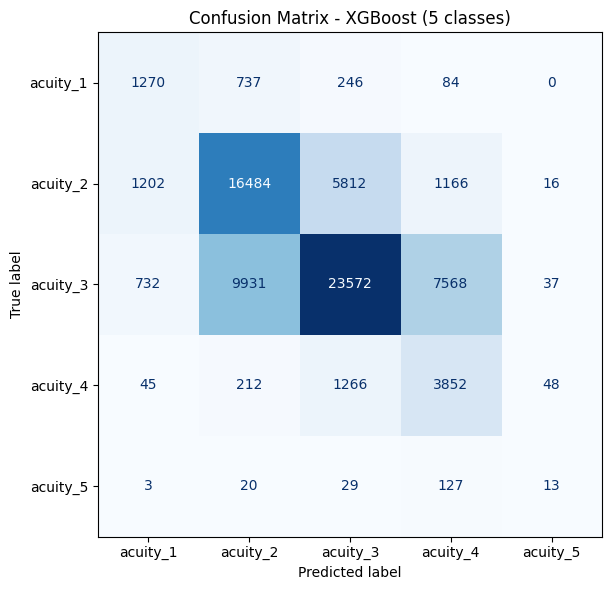

In [27]:
qwk_5 = cohen_kappa_score(y_test_5, y_pred_5c, weights='quadratic')
print(f"Quadratic Weighted Kappa (5 classes): {qwk_5:.4f}")
print(
    classification_report(
        y_test_5,
        y_pred_5c,
        labels=[0, 1, 2, 3, 4],
        target_names=ACUITY_LABELS_5,
        zero_division=0,
    )
)

cm_5 = confusion_matrix(y_test_5, y_pred_5c, labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=ACUITY_LABELS_5)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost (5 classes)')
plt.tight_layout()
plt.show()

## 7. XGBoost (4 Classes)

In [29]:
df['acuity_grouped'] = df['acuity'].map({1: 0, 2: 1, 3: 2, 4: 3, 5: 3})

X_4, y_4 = build_feature_matrix(df, target_col='acuity_grouped')
X_train_4, X_val_4, X_test_4, y_train_4, y_val_4, y_test_4, train_idx_4, val_idx_4, test_idx_4 = split_train_val_test_by_subject(
    X_4,
    y_4,
    groups=df['subject_id'],
)
sample_weights_4 = compute_sample_weights(y_train_4)

print(f"Train (4 classes): {X_train_4.shape[0]} observacoes")
print(f"Validation (4 classes): {X_val_4.shape[0]} observacoes")
print(f"Test (4 classes): {X_test_4.shape[0]} observacoes")
print(f"Distribuicao y_4 train: {y_train_4.value_counts().sort_index().to_dict()}")

Train (4 classes): 258559 observacoes
Validation (4 classes): 36381 observacoes
Test (4 classes): 74472 observacoes
Distribuicao y_4 train: {0: 7903, 1: 84991, 2: 146020, 3: 19645}


[0]	validation_0-mlogloss:1.35391
[50]	validation_0-mlogloss:1.02924
[100]	validation_0-mlogloss:0.98163
[150]	validation_0-mlogloss:0.96137
[200]	validation_0-mlogloss:0.95035
[250]	validation_0-mlogloss:0.94279
[300]	validation_0-mlogloss:0.93743
[350]	validation_0-mlogloss:0.93294
[400]	validation_0-mlogloss:0.92895
[450]	validation_0-mlogloss:0.92513
[500]	validation_0-mlogloss:0.92117
[550]	validation_0-mlogloss:0.91754
[600]	validation_0-mlogloss:0.91414
[650]	validation_0-mlogloss:0.91083
[700]	validation_0-mlogloss:0.90780
[750]	validation_0-mlogloss:0.90448
[800]	validation_0-mlogloss:0.90174
[850]	validation_0-mlogloss:0.89858
[900]	validation_0-mlogloss:0.89645
[950]	validation_0-mlogloss:0.89409
[1000]	validation_0-mlogloss:0.89220
[1050]	validation_0-mlogloss:0.89019
[1100]	validation_0-mlogloss:0.88798
[1150]	validation_0-mlogloss:0.88580
[1200]	validation_0-mlogloss:0.88381
[1250]	validation_0-mlogloss:0.88168
[1300]	validation_0-mlogloss:0.88025
[1350]	validation_0-mlog

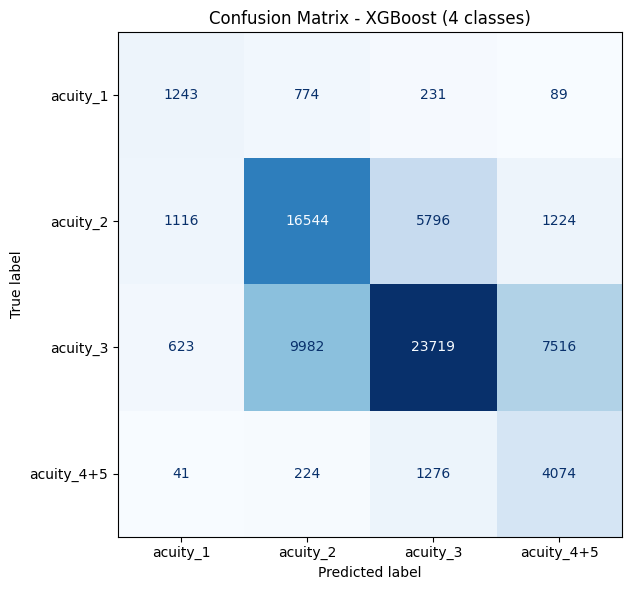

In [30]:
XGB_PARAMS_4 = {
    'n_estimators': 3000,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_4),
    'eval_metric': 'mlogloss',
    'random_state': SEED,
    'n_jobs': -1,
}

xgb_model_4c = xgb.XGBClassifier(**XGB_PARAMS_4)
xgb_model_4c.fit(
    X_train_4,
    y_train_4,
    sample_weight=sample_weights_4,
    eval_set=[(X_val_4, y_val_4)],
    callbacks=build_xgb_callbacks(),
    verbose=False,
)

y_pred_4c = xgb_model_4c.predict(X_test_4)
qwk_4 = cohen_kappa_score(y_test_4, y_pred_4c, weights='quadratic')
baseline_cost_4 = -clinical_cost_score(y_test_4.values, y_pred_4c.astype(int))

print(f"Quadratic Weighted Kappa (4 classes): {qwk_4:.4f}")
print(f"Custo clinico medio (4 classes): {baseline_cost_4:.4f}")
print(
    classification_report(
        y_test_4,
        y_pred_4c,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    )
)

cm_4 = confusion_matrix(y_test_4, y_pred_4c, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=ACUITY_LABELS_4)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost (4 classes)')
plt.tight_layout()
plt.show()

### 7.1 Baseline Summary

In [46]:
# Build summary metrics with safe fallbacks in case some training/evaluation cells were not rerun.
qwk_5_safe = globals().get('qwk_5', np.nan)
qwk_4_safe = globals().get('qwk_4', np.nan)
baseline_cost_4_safe = globals().get('baseline_cost_4', np.nan)
qwk_lgb_safe = globals().get('qwk_lgb', np.nan)
cost_lgb_safe = globals().get('cost_lgb', np.nan)

# Try to recover missing QWK values if true/pred vectors are available.
if pd.isna(qwk_5_safe) and 'y_test_5' in globals():
    if 'y_pred_5c' not in globals() and 'xgb_model_5c' in globals() and 'X_test_5' in globals():
        y_pred_5c = xgb_model_5c.predict(X_test_5)
    if 'y_pred_5c' in globals():
        qwk_5_safe = cohen_kappa_score(y_test_5, y_pred_5c, weights='quadratic')

if pd.isna(qwk_4_safe) and 'y_test_4' in globals():
    if 'y_pred_4c' not in globals() and 'xgb_model_4c' in globals() and 'X_test_4' in globals():
        y_pred_4c = xgb_model_4c.predict(X_test_4)
    if 'y_pred_4c' in globals():
        qwk_4_safe = cohen_kappa_score(y_test_4, y_pred_4c, weights='quadratic')

if pd.isna(baseline_cost_4_safe) and 'y_test_4' in globals() and 'y_pred_4c' in globals():
    baseline_cost_4_safe = -clinical_cost_score(y_test_4.values, y_pred_4c.astype(int))

# Persist qwk_5 as requested.
qwk_5 = qwk_5_safe

metrics_summary = pd.DataFrame(
    [
        {'model': 'XGBoost_5_classes', 'qwk': qwk_5_safe, 'clinical_cost': np.nan},
        {'model': 'XGBoost_4_classes', 'qwk': qwk_4_safe, 'clinical_cost': baseline_cost_4_safe},
        {
            'model': 'LightGBM_4_classes',
            'qwk': qwk_lgb_safe,
            'clinical_cost': cost_lgb_safe,
        },
    ]
)
metrics_summary

,model,qwk,clinical_cost
0,XGBoost_5_classes,0.530041,NaN
1,XGBoost_4_classes,0.533615,0.579802
2,LightGBM_4_classes,0.533588,0.576861


## 8. Optuna Tuning

In [ ]:
from optuna.integration import XGBoostPruningCallback


def objective(trial):
    params = {
        # n_estimators fixo alto: early_stopping encontra o valor otimo automaticamente
        'n_estimators': 3000,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'multi:softmax',
        'num_class': len(ACUITY_LABELS_4),
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',  # muito mais rapido
        'random_state': SEED,
        'n_jobs': -1,
    }

    pruning_cb = XGBoostPruningCallback(trial, 'validation_0-mlogloss')

    candidate_model = xgb.XGBClassifier(**params)
    candidate_model.fit(
        X_train_4,
        y_train_4,
        sample_weight=sample_weights_4,
        eval_set=[(X_val_4, y_val_4)],
        callbacks=build_xgb_callbacks(include_logging=False, extra_callbacks=[pruning_cb]),
        verbose=False,
    )

    y_pred_candidate = candidate_model.predict(X_val_4)
    return clinical_cost_score(y_val_4.values, y_pred_candidate.astype(int))

In [ ]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(
    objective,
    n_trials=OPTUNA_N_TRIALS,
    timeout=3600,  # max 1 hora
    show_progress_bar=True,
)

print(f"Melhor custo clinico (Optuna): {-study.best_value:.4f}")
print(f"Melhores hiperparametros: {study.best_params}")

best_params = study.best_params.copy()
best_params.update({
    'n_estimators': 3000,
    'objective': 'multi:softmax',
    'num_class': len(ACUITY_LABELS_4),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
})

xgb_model_4c_optuna = xgb.XGBClassifier(**best_params)
xgb_model_4c_optuna.fit(
    X_train_4,
    y_train_4,
    sample_weight=sample_weights_4,
    eval_set=[(X_val_4, y_val_4)],
    callbacks=build_xgb_callbacks(include_logging=False),
    verbose=False,
)

y_pred_4c_optuna = xgb_model_4c_optuna.predict(X_test_4)
qwk_4_optuna = cohen_kappa_score(y_test_4, y_pred_4c_optuna, weights='quadratic')
optuna_cost_4 = -clinical_cost_score(y_test_4.values, y_pred_4c_optuna.astype(int))

print(f"QWK (Optuna): {qwk_4_optuna:.4f}")
print(f"Custo clinico (Optuna): {optuna_cost_4:.4f}")
print(
    classification_report(
        y_test_4,
        y_pred_4c_optuna,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    )
)


## 9. LightGBM Benchmark

In [ ]:
LGB_PARAMS_4 = {
    'n_estimators': 20000,
    'max_depth': 6,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'objective': 'multiclass',
    'num_class': len(ACUITY_LABELS_4),
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

lgb_model = lgb.LGBMClassifier(**LGB_PARAMS_4)
lgb_model.fit(
    X_train_4,
    y_train_4,
    eval_set=[(X_val_4, y_val_4)],
    callbacks=build_lgb_callbacks(use_lr_scheduler=True),
)

y_pred_lgb = lgb_model.predict(X_test_4).astype(int)
qwk_lgb = cohen_kappa_score(y_test_4, y_pred_lgb, weights='quadratic')
cost_lgb = -clinical_cost_score(y_test_4.values, y_pred_lgb)

print(f"QWK (LightGBM): {qwk_lgb:.4f}")
print(f"Custo clinico (LightGBM): {cost_lgb:.4f}")
print(
    classification_report(
        y_test_4,
        y_pred_lgb,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    )
)

Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 1.00264
[200]	valid_0's multi_logloss: 0.963188
[300]	valid_0's multi_logloss: 0.948056
[400]	valid_0's multi_logloss: 0.93877
[500]	valid_0's multi_logloss: 0.932267
[600]	valid_0's multi_logloss: 0.926778
[700]	valid_0's multi_logloss: 0.921224
[800]	valid_0's multi_logloss: 0.916371
[900]	valid_0's multi_logloss: 0.912024
[1000]	valid_0's multi_logloss: 0.907161
[1100]	valid_0's multi_logloss: 0.905698
[1200]	valid_0's multi_logloss: 0.904269
[1300]	valid_0's multi_logloss: 0.902968
[1400]	valid_0's multi_logloss: 0.90175
[1500]	valid_0's multi_logloss: 0.900338
[1600]	valid_0's multi_logloss: 0.899039
[1700]	valid_0's multi_logloss: 0.897564
[1800]	valid_0's multi_logloss: 0.896333
[1900]	valid_0's multi_logloss: 0.895137
[2000]	valid_0's multi_logloss: 0.893838
[2100]	valid_0's multi_logloss: 0.893258
[2200]	valid_0's multi_logloss: 0.892745
[2300]	valid_0's multi_logloss: 0.892318
[2400]	v

## 10. GroupKFold Cross-Validation

In [32]:
# Group-aware KFold cross-validation (subject-level) for the 4-class setup.
# This avoids data leakage between folds for repeated patients.

gkf = GroupKFold(n_splits=KFOLD_SPLITS)
groups_4 = df['subject_id']

xgb_params_base = globals().get(
    'XGB_PARAMS_4',
    {
        'n_estimators': 10000,
        'max_depth': 6,
        'learning_rate': 0.05,
        'objective': 'multi:softmax',
        'num_class': len(ACUITY_LABELS_4),
        'eval_metric': 'mlogloss',
        'random_state': SEED,
        'n_jobs': -1,
    },
)
lgb_params_base = globals().get(
    'LGB_PARAMS_4',
    {
        'n_estimators': 10000,
        'max_depth': 6,
        'learning_rate': 0.1,
        'num_leaves': 63,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'objective': 'multiclass',
        'num_class': len(ACUITY_LABELS_4),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': 100,
    },
)

# Keep CV runtime manageable while preserving the model family.
xgb_params_kfold = xgb_params_base.copy()
xgb_params_kfold['n_estimators'] = min(xgb_params_kfold.get('n_estimators', 1000), 1000)

lgb_params_kfold = lgb_params_base.copy()
lgb_params_kfold['n_estimators'] = min(lgb_params_kfold.get('n_estimators', 1000), 1000)

kfold_rows = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_4, y_4, groups=groups_4), start=1):
    X_train_fold = X_4.iloc[train_idx]
    X_val_fold = X_4.iloc[val_idx]
    y_train_fold = y_4.iloc[train_idx]
    y_val_fold = y_4.iloc[val_idx]

    sample_weights_fold = compute_sample_weights(y_train_fold)

    xgb_fold_model = xgb.XGBClassifier(**xgb_params_kfold)
    xgb_fold_model.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=sample_weights_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=build_xgb_callbacks(),
        verbose=False,
    )
    y_pred_xgb_fold = xgb_fold_model.predict(X_val_fold)
    kfold_rows.append(
        {
            'model': 'XGBoost_4_classes',
            'fold': fold,
            'qwk': cohen_kappa_score(y_val_fold, y_pred_xgb_fold, weights='quadratic'),
            'clinical_cost': -clinical_cost_score(y_val_fold.values, y_pred_xgb_fold.astype(int)),
        }
    )

    lgb_fold_model = lgb.LGBMClassifier(**lgb_params_kfold)
    lgb_fold_model.fit(
        X_train_fold,
        y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=build_lgb_callbacks(use_lr_scheduler=True),
    )
    y_pred_lgb_fold = lgb_fold_model.predict(X_val_fold).astype(int)
    kfold_rows.append(
        {
            'model': 'LightGBM_4_classes',
            'fold': fold,
            'qwk': cohen_kappa_score(y_val_fold, y_pred_lgb_fold, weights='quadratic'),
            'clinical_cost': -clinical_cost_score(y_val_fold.values, y_pred_lgb_fold),
        }
    )

kfold_fold_metrics = pd.DataFrame(kfold_rows).sort_values(['model', 'fold']).reset_index(drop=True)
kfold_summary_metrics = (
    kfold_fold_metrics.groupby('model')[['qwk', 'clinical_cost']]
    .agg(['mean', 'std'])
    .round(4)
)

print('Fold a fold:')
display(kfold_fold_metrics)
print('\nResumo (media e desvio padrao):')
display(kfold_summary_metrics)

[0]	validation_0-mlogloss:1.35437
[1]	validation_0-mlogloss:1.32711
[2]	validation_0-mlogloss:1.30331
[3]	validation_0-mlogloss:1.28185
[4]	validation_0-mlogloss:1.26342
[5]	validation_0-mlogloss:1.24690
[6]	validation_0-mlogloss:1.23223
[7]	validation_0-mlogloss:1.21940
[8]	validation_0-mlogloss:1.20747
[9]	validation_0-mlogloss:1.19682
[10]	validation_0-mlogloss:1.18682
[11]	validation_0-mlogloss:1.17740
[12]	validation_0-mlogloss:1.16940
[13]	validation_0-mlogloss:1.16116
[14]	validation_0-mlogloss:1.15323
[15]	validation_0-mlogloss:1.14618
[16]	validation_0-mlogloss:1.14005
[17]	validation_0-mlogloss:1.13389
[18]	validation_0-mlogloss:1.12816
[19]	validation_0-mlogloss:1.12324
[20]	validation_0-mlogloss:1.11792
[21]	validation_0-mlogloss:1.11228
[22]	validation_0-mlogloss:1.10727
[23]	validation_0-mlogloss:1.10216
[24]	validation_0-mlogloss:1.09763
[25]	validation_0-mlogloss:1.09365
[26]	validation_0-mlogloss:1.08961
[27]	validation_0-mlogloss:1.08594
[28]	validation_0-mlogloss:1.0

,model,fold,qwk,clinical_cost
0,LightGBM_4_classes,1,0.518370,0.622768
1,LightGBM_4_classes,2,0.522541,0.621618
2,LightGBM_4_classes,3,0.513819,0.628854
3,LightGBM_4_classes,4,0.518409,0.622411
4,LightGBM_4_classes,5,0.511413,0.637151
5,XGBoost_4_classes,1,0.518559,0.618559
6,XGBoost_4_classes,2,0.524374,0.615717
7,XGBoost_4_classes,3,0.515405,0.623968
8,XGBoost_4_classes,4,0.520242,0.612260
9,XGBoost_4_classes,5,0.515368,0.632306



Resumo (media e desvio padrao):


qwk         clinical_cost        
                      mean     std          mean     std
model                                                   
LightGBM_4_classes  0.5169  0.0044        0.6266  0.0066
XGBoost_4_classes   0.5188  0.0038        0.6206  0.0078

## 11. SHAP Explainability

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


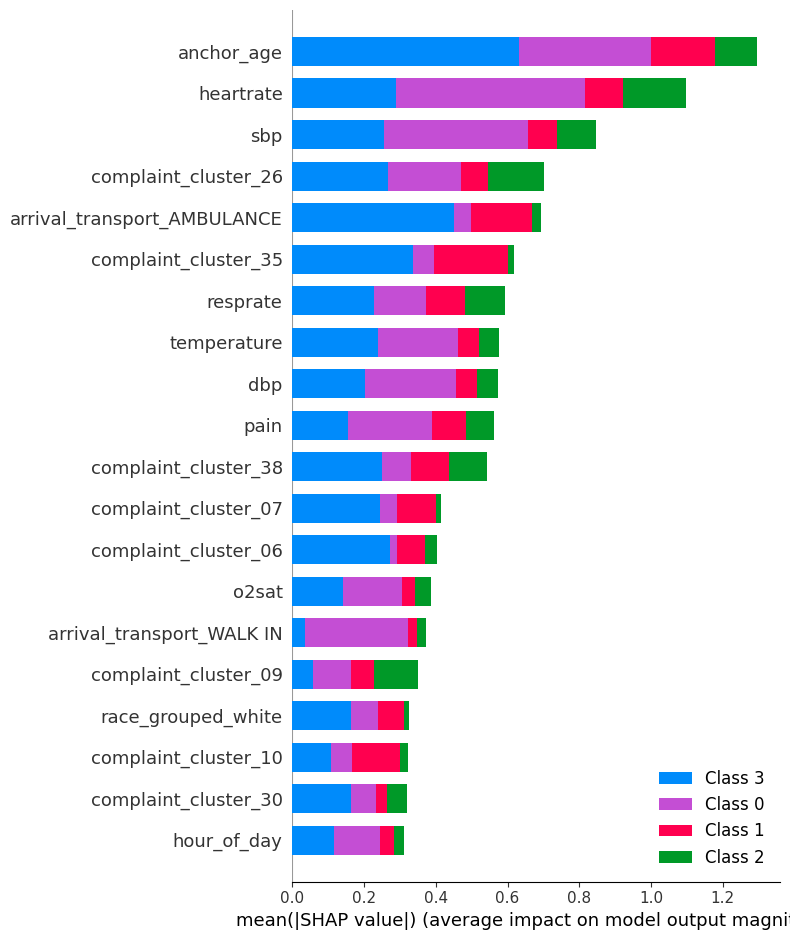

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


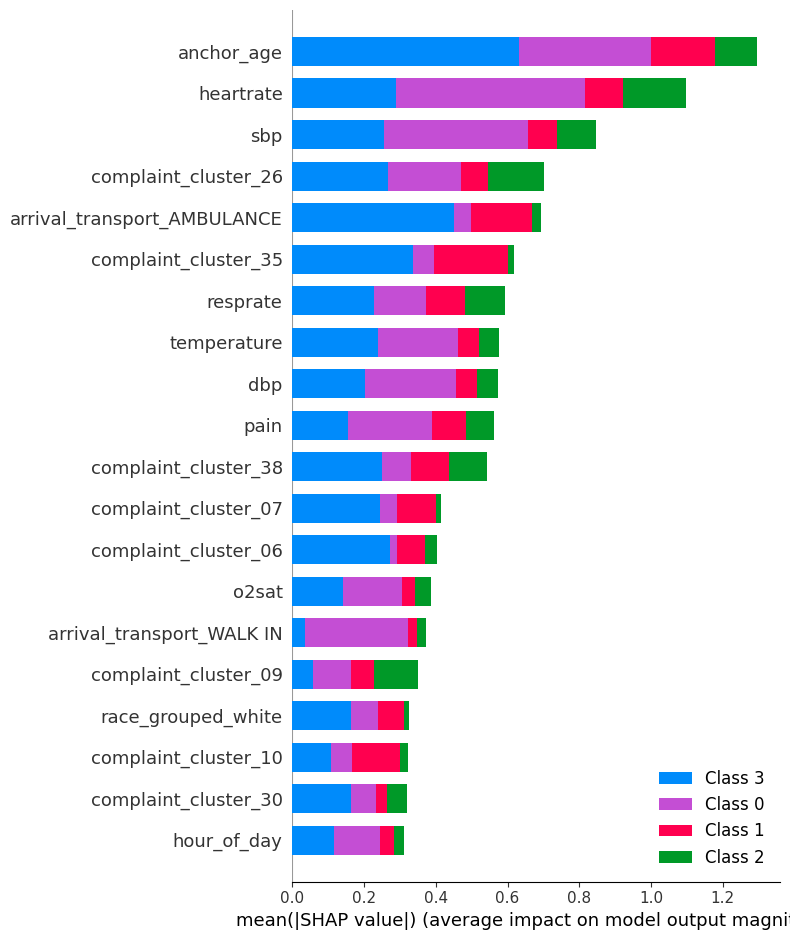

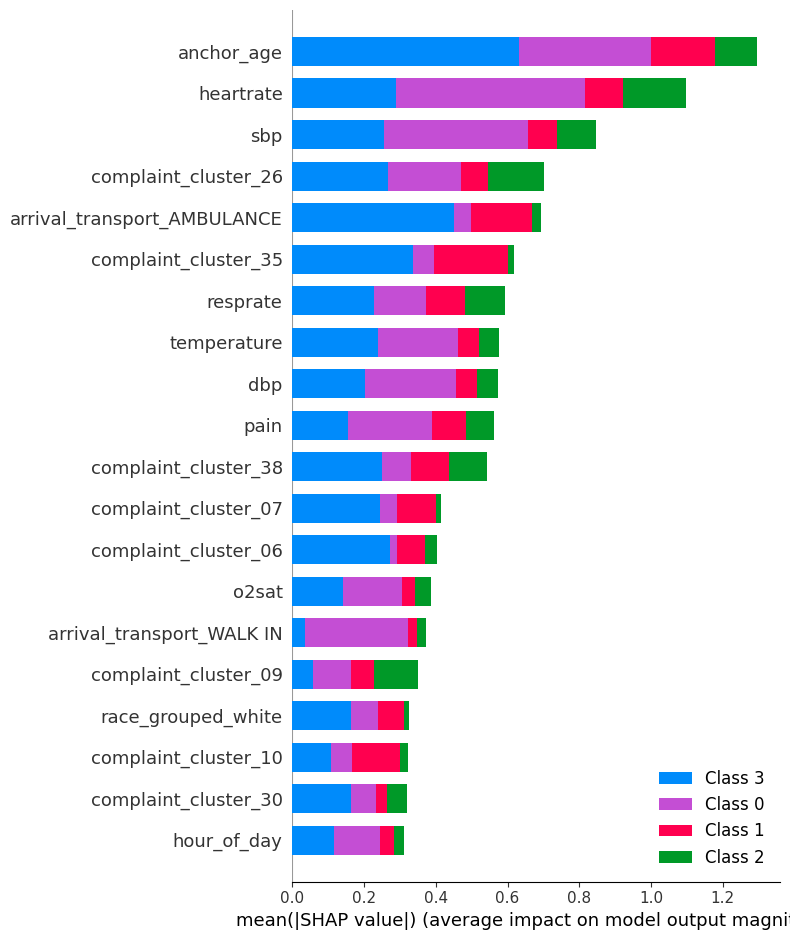

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


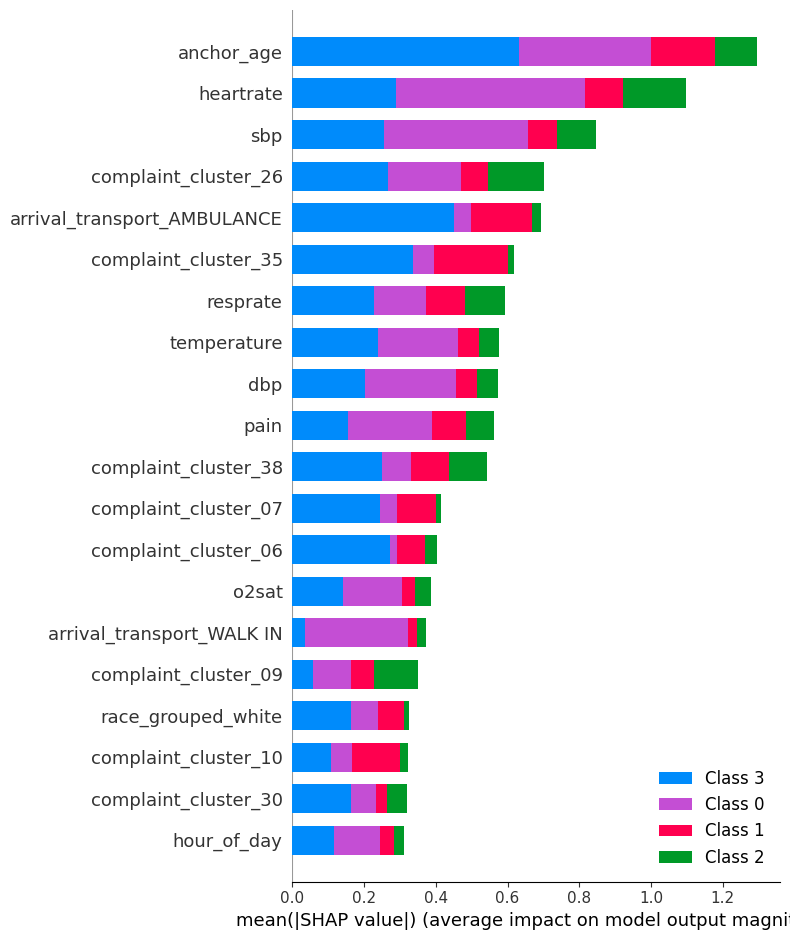

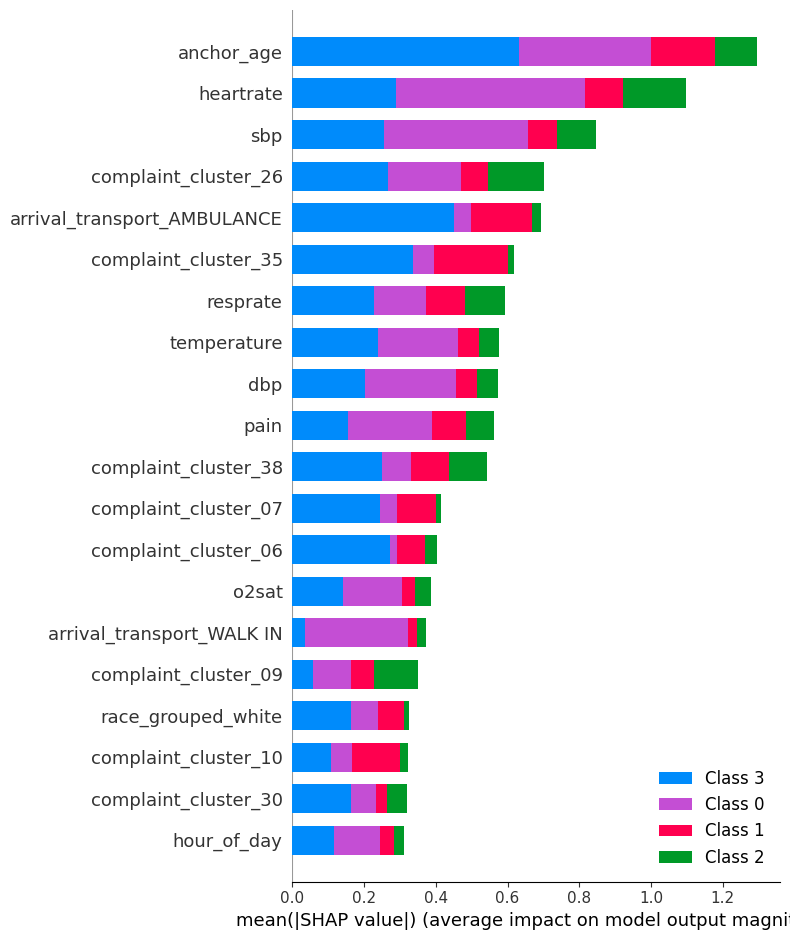


=== SHAP: LightGBM ===


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


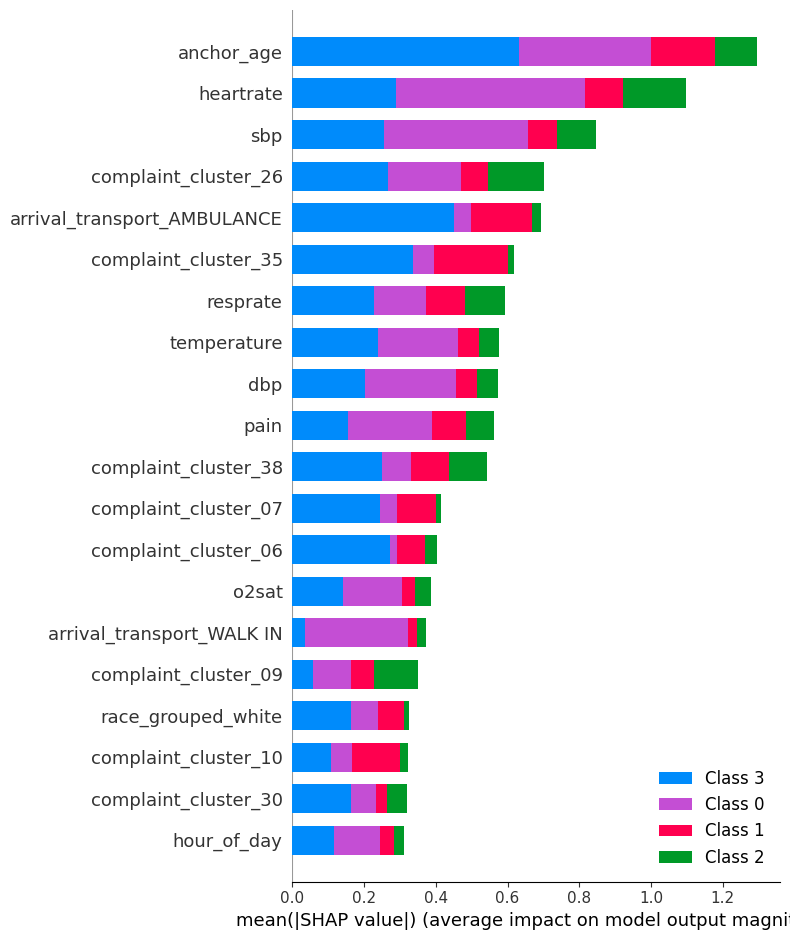

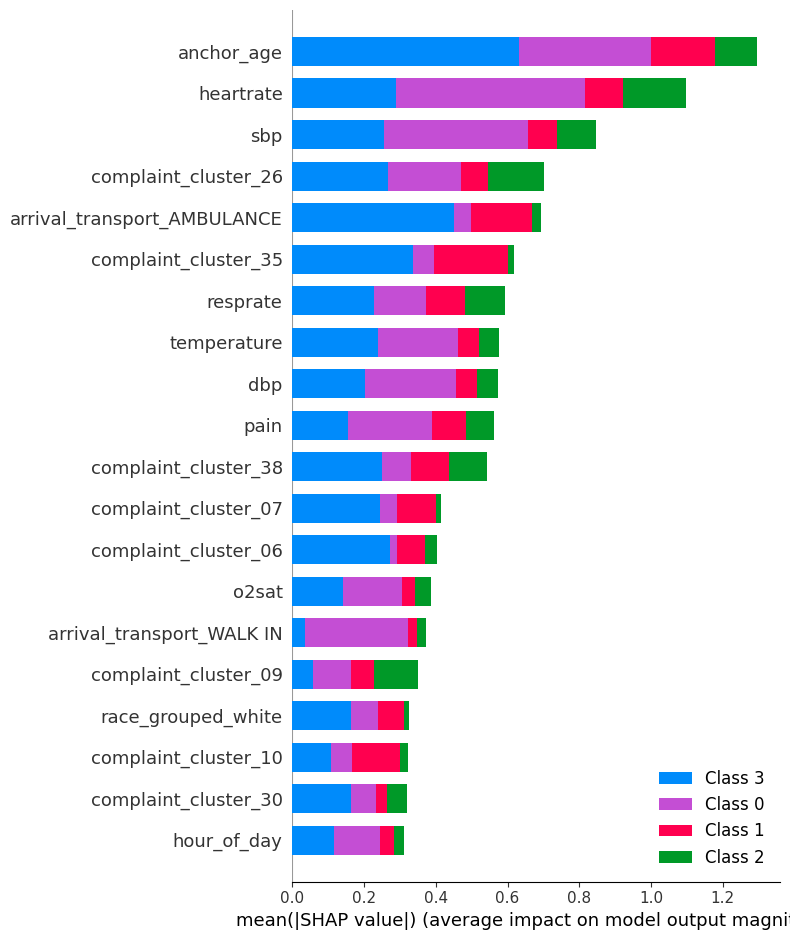


=== SHAP: LightGBM ===


,feature,mean_abs_shap_lgb
0,anchor_age,0.244844
1,complaint_cluster_26,0.230051
2,complaint_cluster_35,0.167520
3,arrival_transport_AMBULANCE,0.156895
4,complaint_cluster_38,0.145818
5,heartrate,0.128103
6,complaint_cluster_07,0.116414
7,complaint_cluster_06,0.115269
8,resprate,0.112895
9,pain,0.111380


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


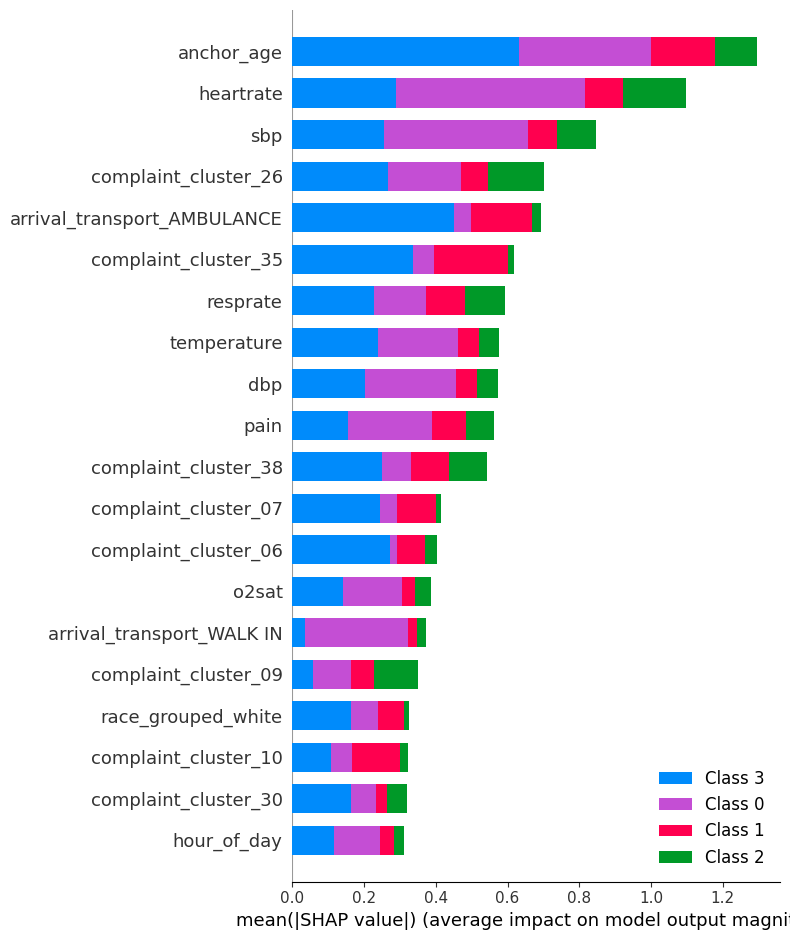

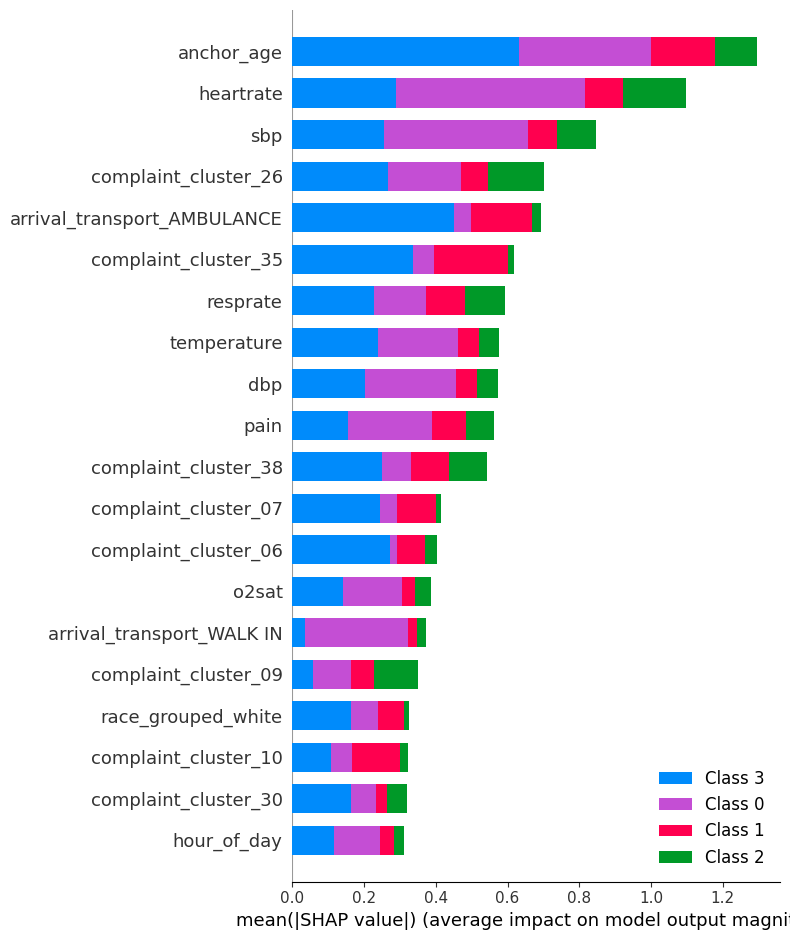


=== SHAP: LightGBM ===


,feature,mean_abs_shap_lgb
0,anchor_age,0.244844
1,complaint_cluster_26,0.230051
2,complaint_cluster_35,0.167520
3,arrival_transport_AMBULANCE,0.156895
4,complaint_cluster_38,0.145818
5,heartrate,0.128103
6,complaint_cluster_07,0.116414
7,complaint_cluster_06,0.115269
8,resprate,0.112895
9,pain,0.111380


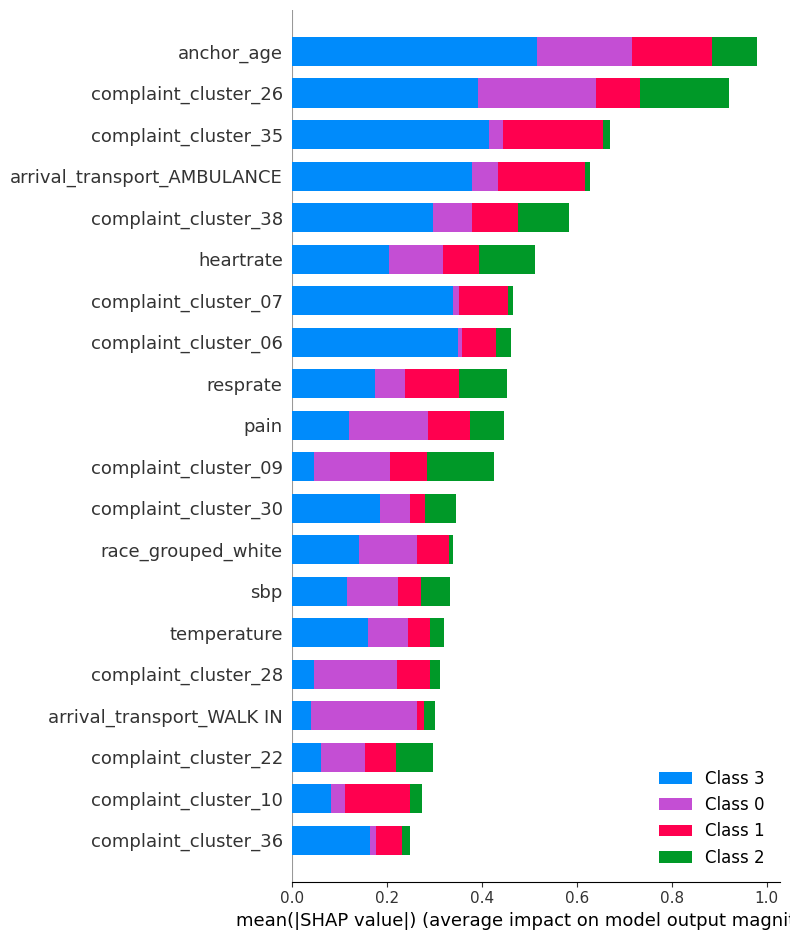

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


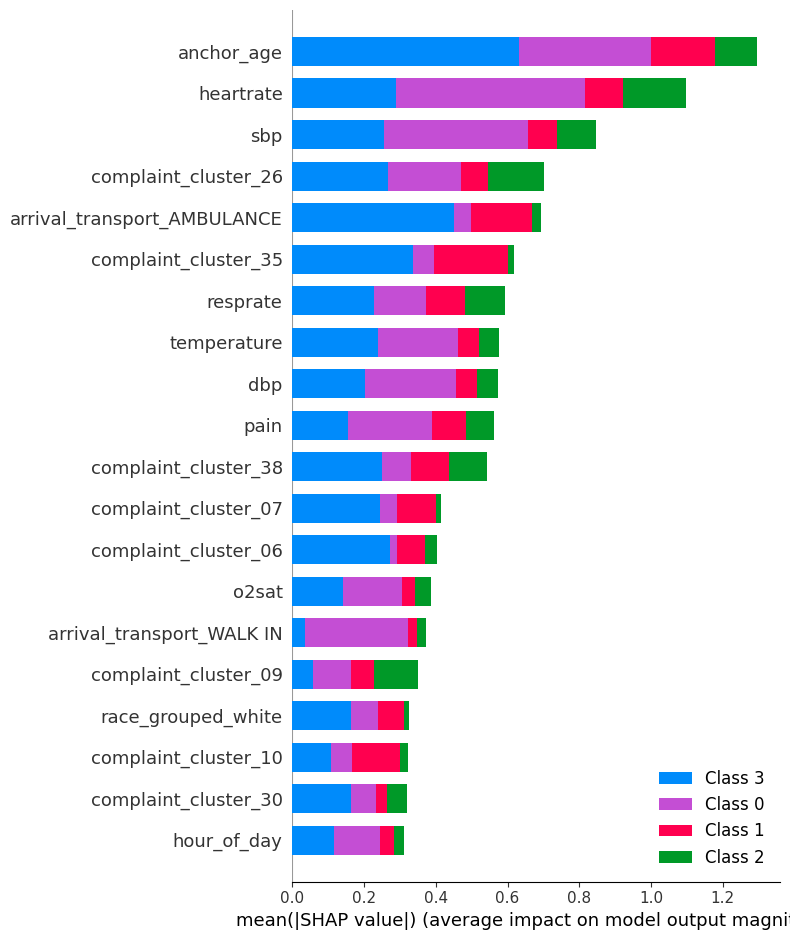

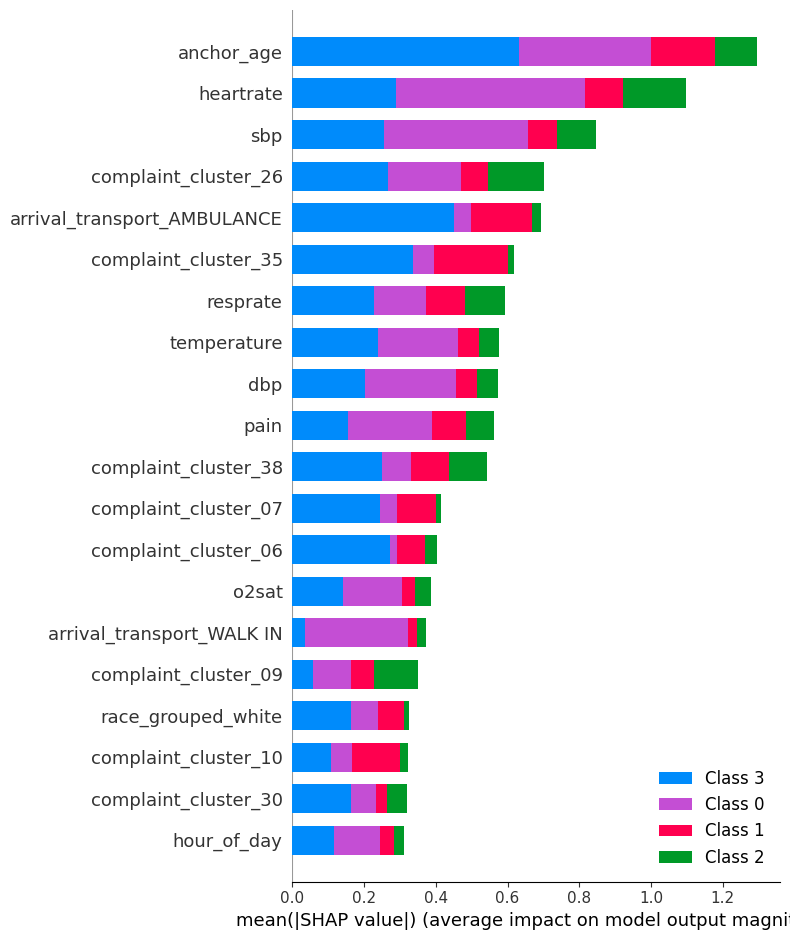


=== SHAP: LightGBM ===


,feature,mean_abs_shap_lgb
0,anchor_age,0.244844
1,complaint_cluster_26,0.230051
2,complaint_cluster_35,0.167520
3,arrival_transport_AMBULANCE,0.156895
4,complaint_cluster_38,0.145818
5,heartrate,0.128103
6,complaint_cluster_07,0.116414
7,complaint_cluster_06,0.115269
8,resprate,0.112895
9,pain,0.111380


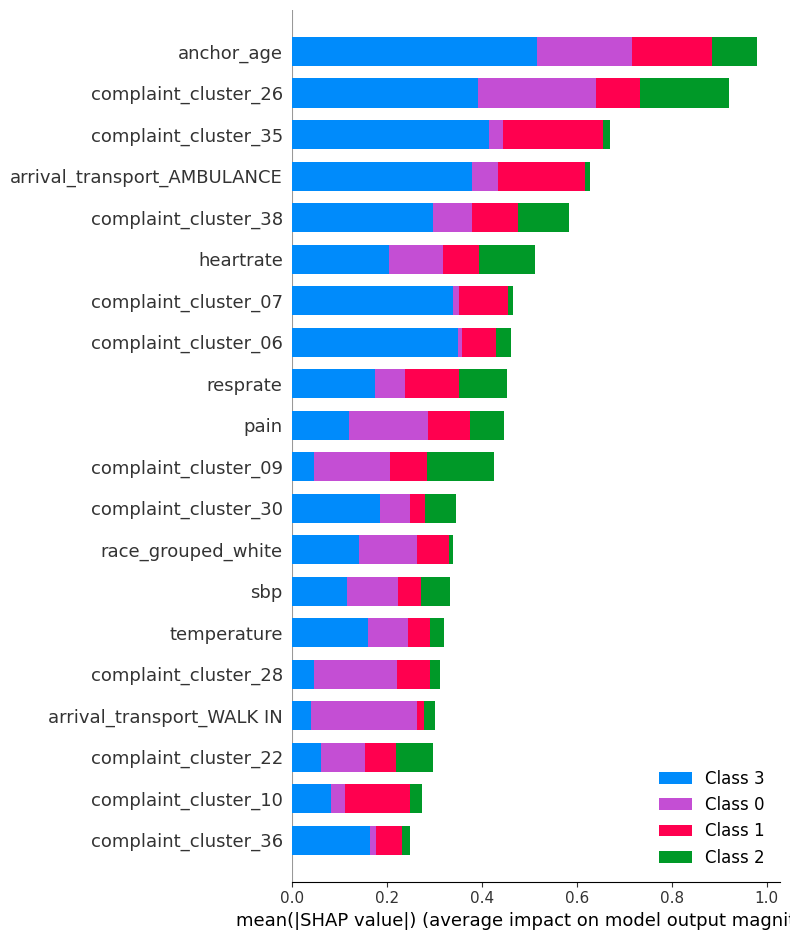

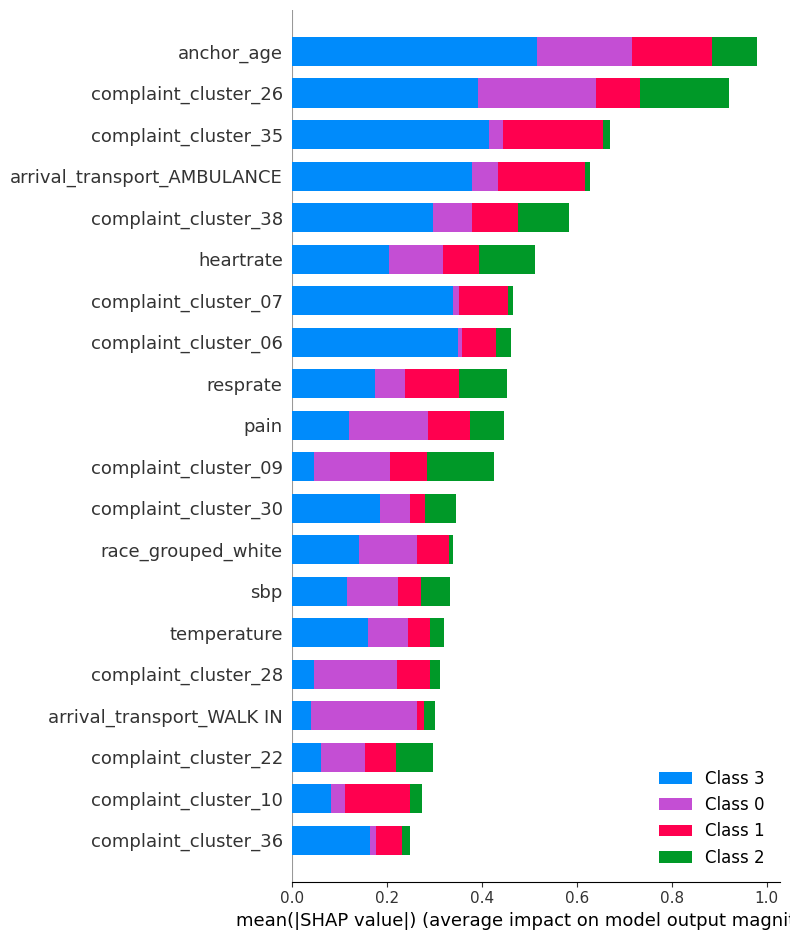


=== Comparacao XGBoost vs LightGBM ===
Sobreposicao Top-20: 17/23
Jaccard Top-20: 0.7391


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


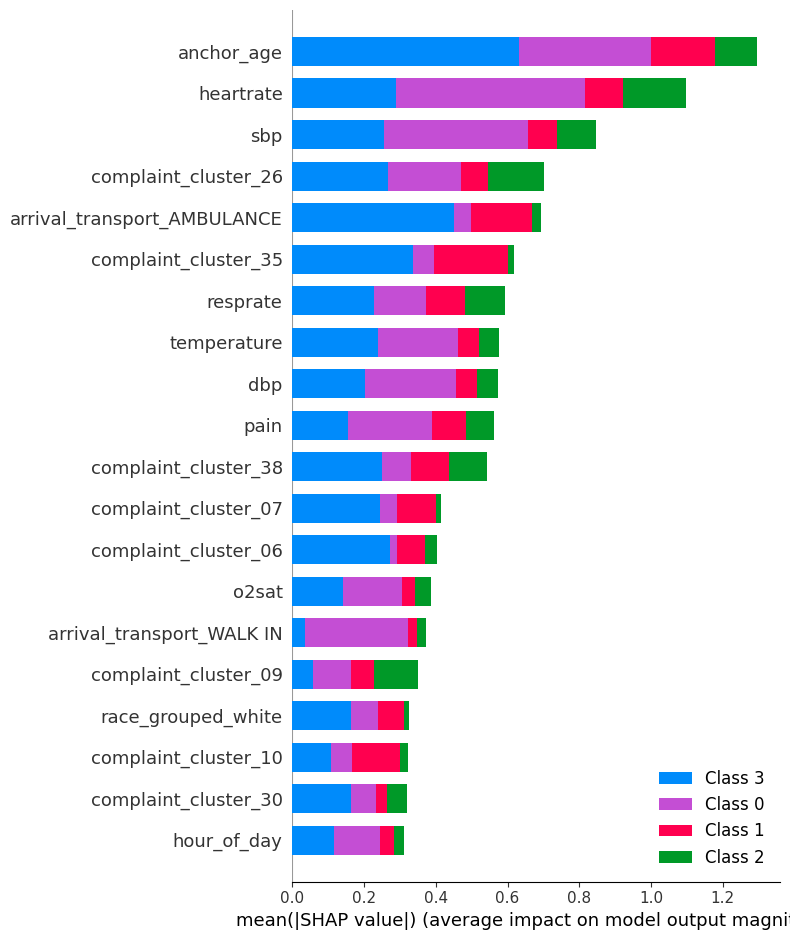

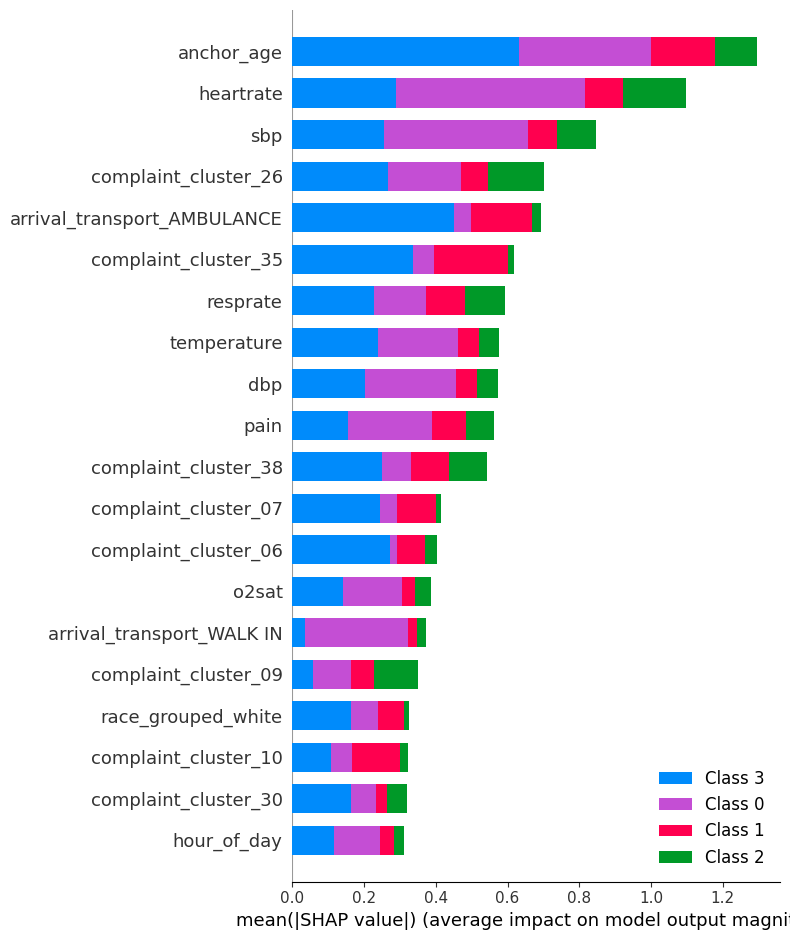


=== SHAP: LightGBM ===


,feature,mean_abs_shap_lgb
0,anchor_age,0.244844
1,complaint_cluster_26,0.230051
2,complaint_cluster_35,0.167520
3,arrival_transport_AMBULANCE,0.156895
4,complaint_cluster_38,0.145818
5,heartrate,0.128103
6,complaint_cluster_07,0.116414
7,complaint_cluster_06,0.115269
8,resprate,0.112895
9,pain,0.111380


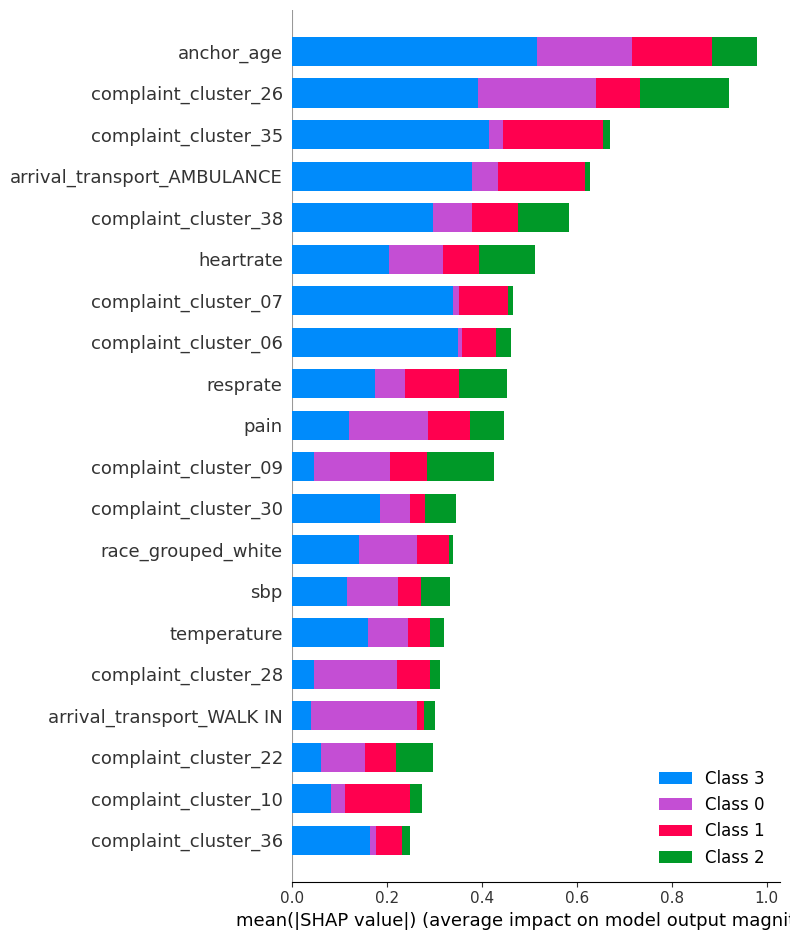

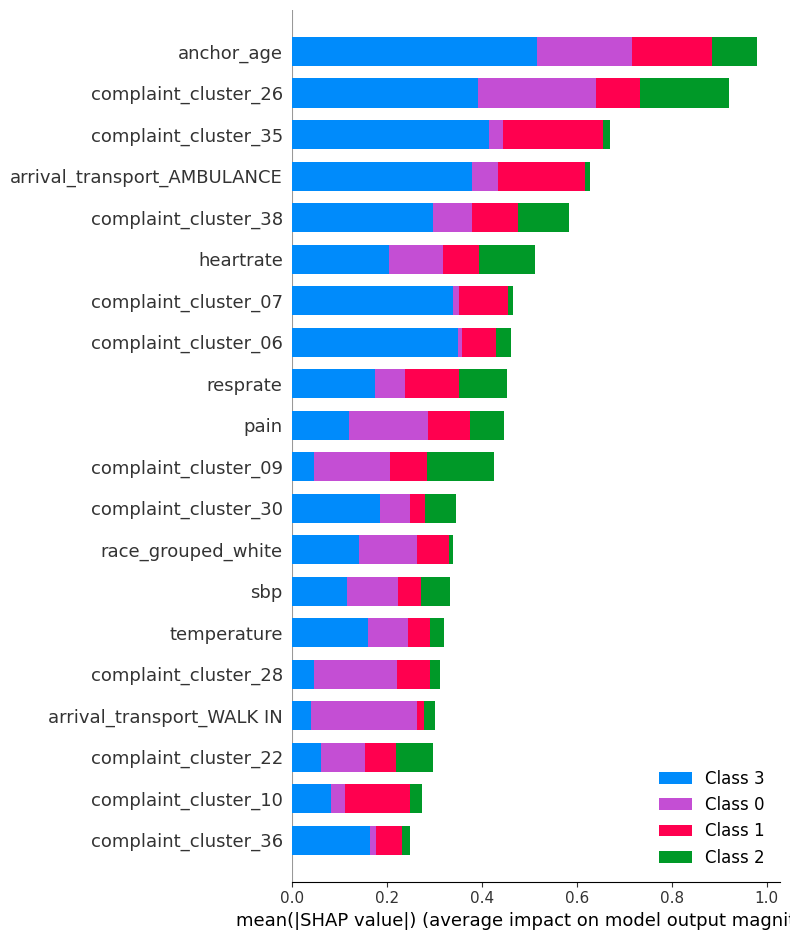


=== Comparacao XGBoost vs LightGBM ===
Sobreposicao Top-20: 17/23
Jaccard Top-20: 0.7391


,feature,mean_abs_shap_xgb,mean_abs_shap_lgb,rank_xgb,rank_lgb,rank_gap_abs,importance_gap_abs
0,heartrate,0.274146,0.128103,2,6,4,0.146044
1,sbp,0.212034,0.082808,3,14,11,0.129226
2,dbp,0.143575,0.061541,9,21,12,0.082034
3,anchor_age,0.323823,0.244844,1,1,0,0.078979
4,temperature,0.143712,0.080017,8,15,7,0.063695
5,complaint_cluster_26,0.175340,0.230051,4,2,2,0.054711
6,o2sat,0.096519,0.048009,14,27,13,0.048510
7,resprate,0.147981,0.112895,7,9,2,0.035086
8,pain,0.140815,0.111380,10,10,0,0.029434
9,hour_cos,0.065481,0.041450,24,32,8,0.024031


Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para SHAP.
Amostra SHAP: 5000 linhas x 69 features
Modelo XGBoost usado: XGBoost_4_classes
Modelo LightGBM usado: LightGBM_4_classes

=== SHAP: XGBoost ===


,feature,mean_abs_shap_xgb
0,anchor_age,0.323823
1,heartrate,0.274146
2,sbp,0.212034
3,complaint_cluster_26,0.175340
4,arrival_transport_AMBULANCE,0.173577
5,complaint_cluster_35,0.154585
6,resprate,0.147981
7,temperature,0.143712
8,dbp,0.143575
9,pain,0.140815


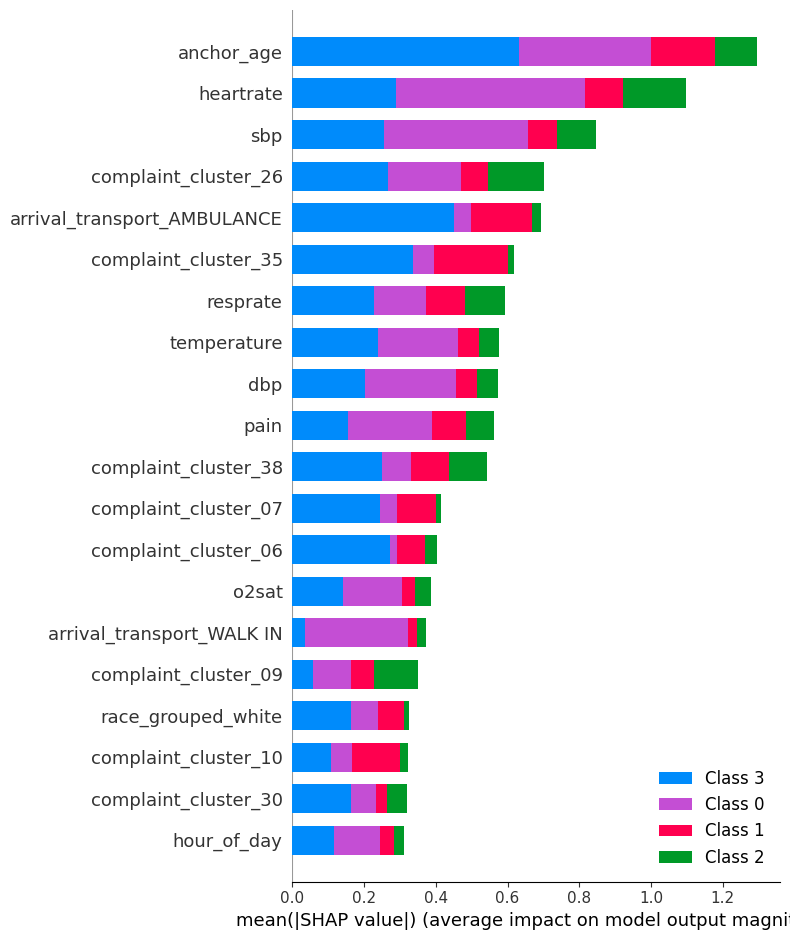

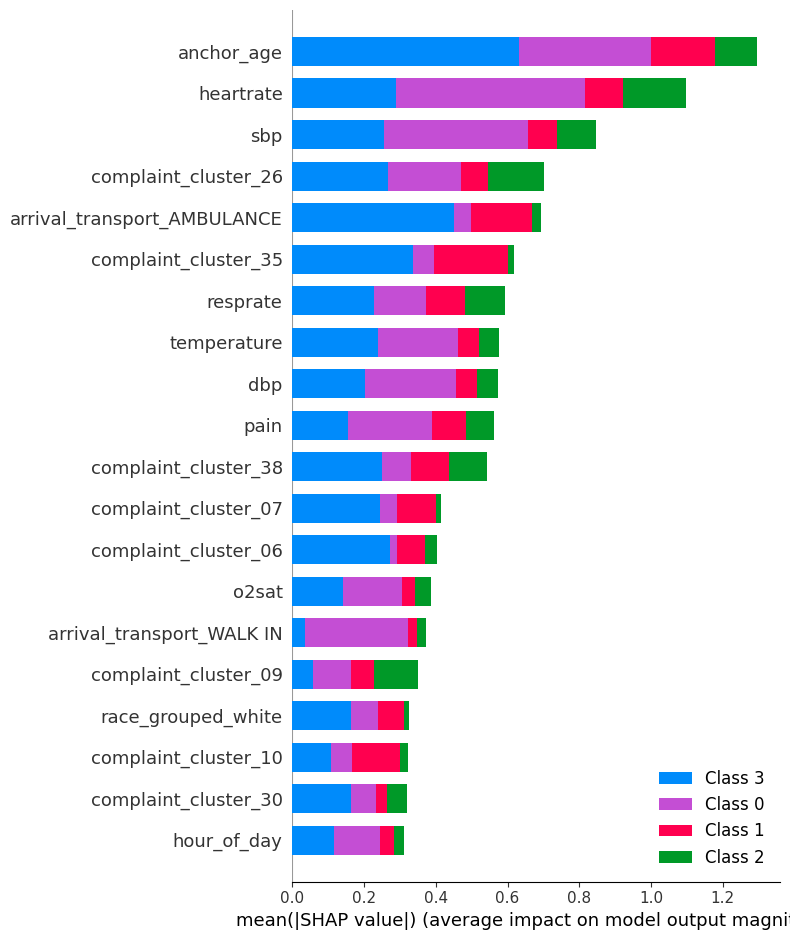


=== SHAP: LightGBM ===


,feature,mean_abs_shap_lgb
0,anchor_age,0.244844
1,complaint_cluster_26,0.230051
2,complaint_cluster_35,0.167520
3,arrival_transport_AMBULANCE,0.156895
4,complaint_cluster_38,0.145818
5,heartrate,0.128103
6,complaint_cluster_07,0.116414
7,complaint_cluster_06,0.115269
8,resprate,0.112895
9,pain,0.111380


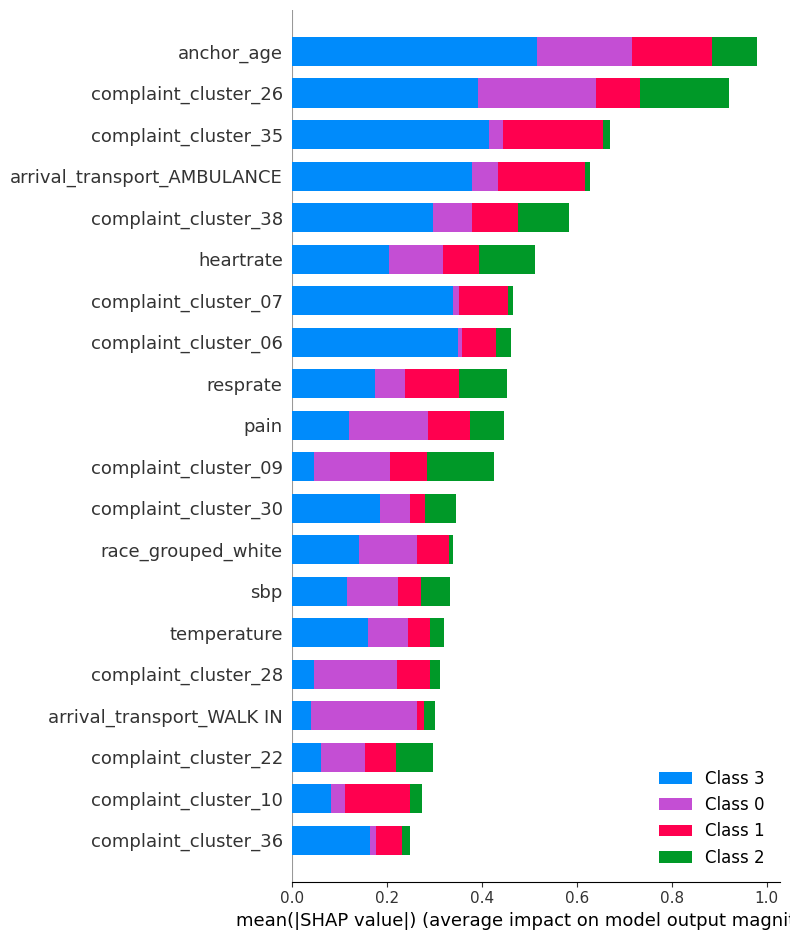

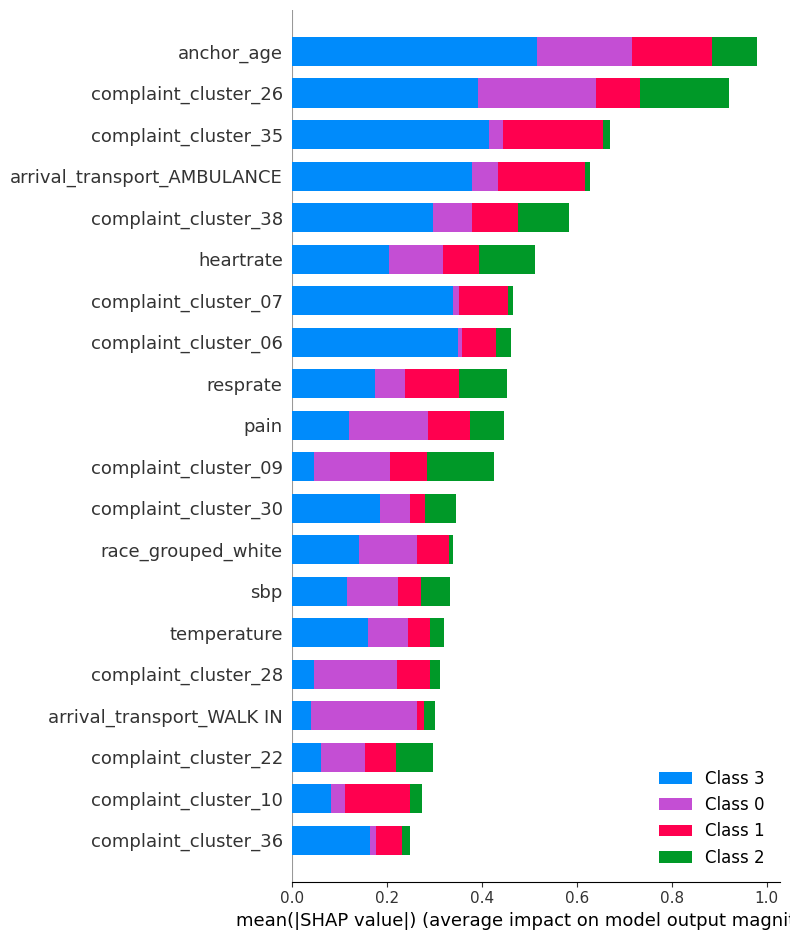


=== Comparacao XGBoost vs LightGBM ===
Sobreposicao Top-20: 17/23
Jaccard Top-20: 0.7391


,feature,mean_abs_shap_xgb,mean_abs_shap_lgb,rank_xgb,rank_lgb,rank_gap_abs,importance_gap_abs
0,heartrate,0.274146,0.128103,2,6,4,0.146044
1,sbp,0.212034,0.082808,3,14,11,0.129226
2,dbp,0.143575,0.061541,9,21,12,0.082034
3,anchor_age,0.323823,0.244844,1,1,0,0.078979
4,temperature,0.143712,0.080017,8,15,7,0.063695
5,complaint_cluster_26,0.175340,0.230051,4,2,2,0.054711
6,o2sat,0.096519,0.048009,14,27,13,0.048510
7,resprate,0.147981,0.112895,7,9,2,0.035086
8,pain,0.140815,0.111380,10,10,0,0.029434
9,hour_cos,0.065481,0.041450,24,32,8,0.024031


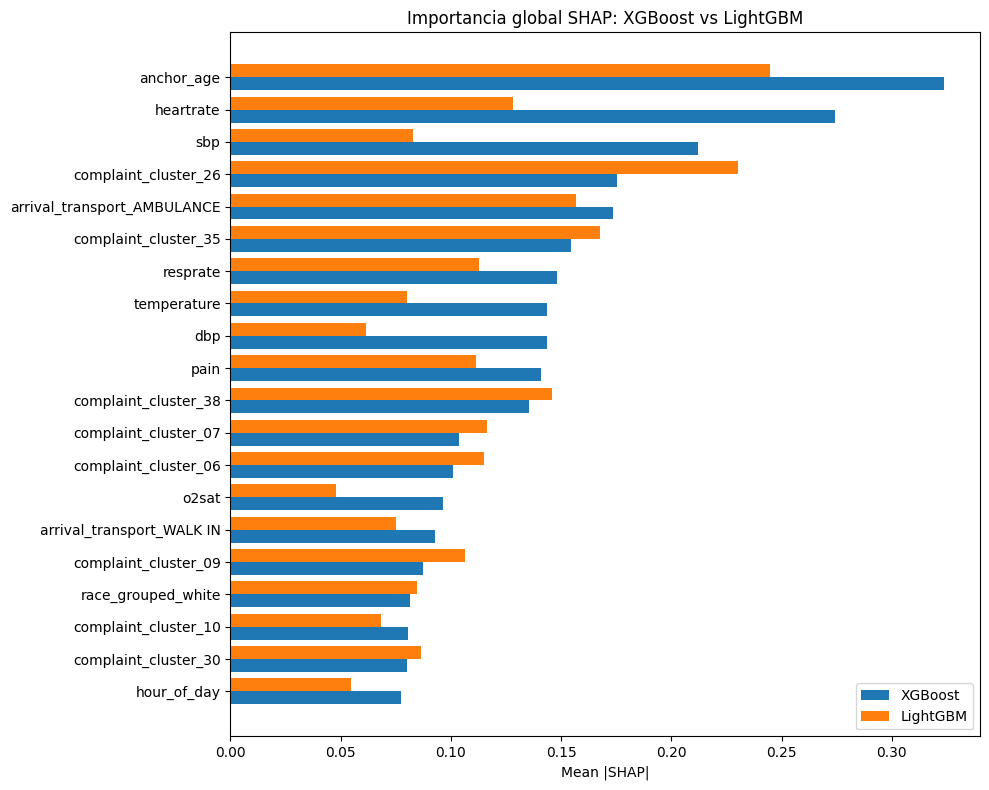

In [36]:
# SHAP explainability for the 4-class setup: separate outputs for XGBoost and LightGBM,
# followed by a direct comparison table and plot.
if "shap" not in globals():
    raise NameError("Execute a celula de imports (Secao 1) para carregar o pacote shap antes desta etapa.")

if "X_test_4" not in globals() or "y_test_4" not in globals():
    raise ValueError("X_test_4 e y_test_4 nao estao disponiveis. Execute a secao 7 para preparar os dados.")

xgb_model_to_explain = globals().get("xgb_model_4c_optuna") or globals().get("xgb_model_4c")
lgb_model_to_explain = globals().get("lgb_model")

if xgb_model_to_explain is None:
    raise ValueError("Modelo XGBoost 4 classes nao encontrado. Execute a secao 7 ou 8 antes do SHAP.")
if lgb_model_to_explain is None:
    # fallback para modelos LightGBM com nomes alternativos no notebook
    for candidate_name in ("lgb_model_4c_optuna", "lgb_model_4c", "lgb_fold_model"):
        candidate_model = globals().get(candidate_name)
        if candidate_model is not None:
            lgb_model_to_explain = candidate_model
            print(f"Aviso: 'lgb_model' nao encontrado; usando '{candidate_name}' para SHAP.")
            break

    if lgb_model_to_explain is None:
        raise ValueError("Modelo LightGBM 4 classes nao encontrado. Execute a secao 9 antes do SHAP.")

xgb_model_name = (
    "XGBoost_4_classes_optuna"
    if "xgb_model_4c_optuna" in globals() and globals().get("xgb_model_4c_optuna") is not None
    else "XGBoost_4_classes"
)

sample_size = min(SHAP_SAMPLE_SIZE, len(X_test_4))
if sample_size < len(X_test_4):
    X_explain = X_test_4.sample(n=sample_size, random_state=SEED)
else:
    X_explain = X_test_4.copy()

print(f"Amostra SHAP: {X_explain.shape[0]} linhas x {X_explain.shape[1]} features")
print(f"Modelo XGBoost usado: {xgb_model_name}")
print("Modelo LightGBM usado: LightGBM_4_classes")


def mean_abs_shap_per_feature(shap_values):
    if isinstance(shap_values, list):
        shap_stack = np.stack([np.abs(class_values) for class_values in shap_values], axis=-1)
        return shap_stack.mean(axis=(0, 2))

    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        return np.abs(shap_array).mean(axis=(0, 2))
    if shap_array.ndim == 2:
        return np.abs(shap_array).mean(axis=0)

    raise ValueError(f"Formato SHAP inesperado: {shap_array.shape}")


def shap_values_for_plot(shap_values):
    if isinstance(shap_values, list):
        return shap_values

    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        return [shap_array[:, :, class_idx] for class_idx in range(shap_array.shape[2])]

    return shap_array


def build_shap_importance(model, X_frame, model_tag):
    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(X_frame)
    importance_df = (
        pd.DataFrame(
            {
                "feature": X_frame.columns,
                f"mean_abs_shap_{model_tag}": mean_abs_shap_per_feature(shap_values_raw),
            }
        )
        .sort_values(f"mean_abs_shap_{model_tag}", ascending=False)
        .reset_index(drop=True)
    )
    return shap_values_raw, importance_df


# 1) XGBoost SHAP (separate)
print("\n=== SHAP: XGBoost ===")
shap_values_xgb_raw, shap_importance_xgb = build_shap_importance(
    xgb_model_to_explain,
    X_explain,
    "xgb",
)
display(shap_importance_xgb.head(SHAP_MAX_DISPLAY))

shap.summary_plot(
    shap_values_for_plot(shap_values_xgb_raw),
    X_explain,
    plot_type="bar",
    max_display=SHAP_MAX_DISPLAY,
)
shap.summary_plot(
    shap_values_for_plot(shap_values_xgb_raw),
    X_explain,
    max_display=SHAP_MAX_DISPLAY,
)


# 2) LightGBM SHAP (separate)
print("\n=== SHAP: LightGBM ===")
shap_values_lgb_raw, shap_importance_lgb = build_shap_importance(
    lgb_model_to_explain,
    X_explain,
    "lgb",
)
display(shap_importance_lgb.head(SHAP_MAX_DISPLAY))

shap.summary_plot(
    shap_values_for_plot(shap_values_lgb_raw),
    X_explain,
    plot_type="bar",
    max_display=SHAP_MAX_DISPLAY,
)
shap.summary_plot(
    shap_values_for_plot(shap_values_lgb_raw),
    X_explain,
    max_display=SHAP_MAX_DISPLAY,
)


# 3) XGBoost vs LightGBM comparison
print("\n=== Comparacao XGBoost vs LightGBM ===")
shap_comparison = (
    shap_importance_xgb.merge(shap_importance_lgb, on="feature", how="outer")
    .fillna(0.0)
)

shap_comparison["rank_xgb"] = shap_comparison["mean_abs_shap_xgb"].rank(
    method="dense",
    ascending=False,
).astype(int)
shap_comparison["rank_lgb"] = shap_comparison["mean_abs_shap_lgb"].rank(
    method="dense",
    ascending=False,
).astype(int)
shap_comparison["rank_gap_abs"] = (shap_comparison["rank_xgb"] - shap_comparison["rank_lgb"]).abs()
shap_comparison["importance_gap_abs"] = (
    shap_comparison["mean_abs_shap_xgb"] - shap_comparison["mean_abs_shap_lgb"]
).abs()

shap_comparison = shap_comparison.sort_values(
    "importance_gap_abs",
    ascending=False,
).reset_index(drop=True)

xgb_top_set = set(shap_importance_xgb.head(SHAP_MAX_DISPLAY)["feature"])
lgb_top_set = set(shap_importance_lgb.head(SHAP_MAX_DISPLAY)["feature"])
intersection_count = len(xgb_top_set & lgb_top_set)
union_count = len(xgb_top_set | lgb_top_set)
jaccard_top_features = intersection_count / union_count if union_count else np.nan

print(f"Sobreposicao Top-{SHAP_MAX_DISPLAY}: {intersection_count}/{union_count}")
print(f"Jaccard Top-{SHAP_MAX_DISPLAY}: {jaccard_top_features:.4f}")

display(shap_comparison.head(SHAP_MAX_DISPLAY))

plot_compare = (
    shap_comparison.nlargest(SHAP_MAX_DISPLAY, "mean_abs_shap_xgb")
    .sort_values("mean_abs_shap_xgb", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(plot_compare))
ax.barh(y_pos - 0.2, plot_compare["mean_abs_shap_xgb"], height=0.4, label="XGBoost")
ax.barh(y_pos + 0.2, plot_compare["mean_abs_shap_lgb"], height=0.4, label="LightGBM")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_compare["feature"])
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Importancia global SHAP: XGBoost vs LightGBM")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Ensemble (XGBoost + LightGBM)

Aviso: 'lgb_model' nao encontrado; usando 'lgb_fold_model' para ensemble.
Metodo do ensemble: soft_voting_mean_proba


,model,qwk,clinical_cost
0,XGBoost_4_classes,0.533615,0.579802
1,LightGBM_4_classes,0.555427,0.585106
2,Ensemble_4_classes (soft_voting_mean_proba),0.549611,0.577694



Classification report - Ensemble (4 classes)
              precision    recall  f1-score   support

    acuity_1       0.41      0.65      0.50      2337
    acuity_2       0.62      0.68      0.65     24680
    acuity_3       0.79      0.55      0.65     41840
  acuity_4+5       0.32      0.80      0.45      5615

    accuracy                           0.62     74472
   macro avg       0.53      0.67      0.56     74472
weighted avg       0.68      0.62      0.63     74472



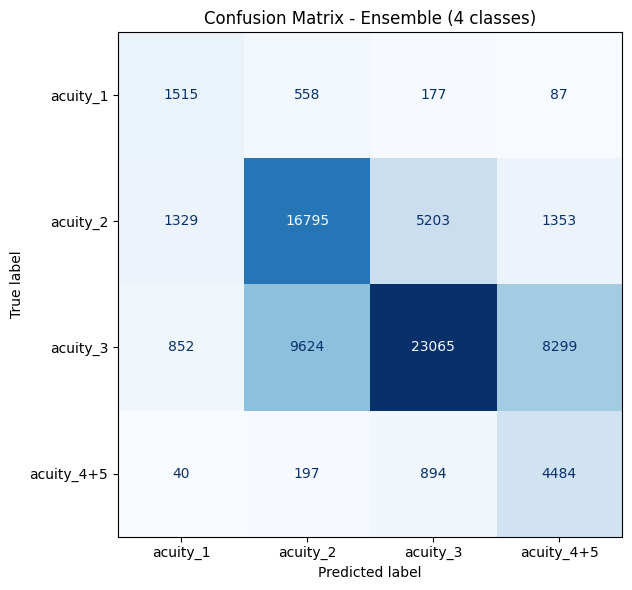

In [42]:
if "X_test_4" not in globals() or "y_test_4" not in globals():
    raise ValueError("X_test_4 e y_test_4 nao estao disponiveis. Execute a secao 7 antes do ensemble.")

xgb_ensemble_model = globals().get("xgb_model_4c_optuna") or globals().get("xgb_model_4c")
if xgb_ensemble_model is None:
    raise ValueError("Modelo XGBoost 4 classes nao encontrado. Execute a secao 7 ou 8 antes do ensemble.")

lgb_ensemble_model = globals().get("lgb_model")
if lgb_ensemble_model is None:
    for candidate_name in ("lgb_model_4c_optuna", "lgb_model_4c", "lgb_fold_model"):
        candidate_model = globals().get(candidate_name)
        if candidate_model is not None:
            lgb_ensemble_model = candidate_model
            print(f"Aviso: 'lgb_model' nao encontrado; usando '{candidate_name}' para ensemble.")
            break

if lgb_ensemble_model is None:
    raise ValueError("Modelo LightGBM 4 classes nao encontrado. Execute a secao 9 antes do ensemble.")


def safe_predict_proba(model, X_frame):
    if not hasattr(model, "predict_proba"):
        return None
    try:
        proba = np.asarray(model.predict_proba(X_frame))
        if proba.ndim != 2 or proba.shape[0] != len(X_frame):
            return None
        return proba
    except Exception:
        return None


y_pred_xgb_ens = np.asarray(xgb_ensemble_model.predict(X_test_4)).astype(int)
y_pred_lgb_ens = np.asarray(lgb_ensemble_model.predict(X_test_4)).astype(int)

proba_xgb_ens = safe_predict_proba(xgb_ensemble_model, X_test_4)
proba_lgb_ens = safe_predict_proba(lgb_ensemble_model, X_test_4)

if (
    proba_xgb_ens is not None
    and proba_lgb_ens is not None
    and proba_xgb_ens.shape == proba_lgb_ens.shape
):
    ensemble_method = "soft_voting_mean_proba"
    proba_ensemble_4 = 0.5 * proba_xgb_ens + 0.5 * proba_lgb_ens
    y_pred_ensemble_4 = np.argmax(proba_ensemble_4, axis=1).astype(int)
else:
    ensemble_method = "hard_voting_fallback_xgb_on_tie"
    # For two models, disagreement is a tie; break ties with XGBoost.
    y_pred_ensemble_4 = np.where(y_pred_xgb_ens == y_pred_lgb_ens, y_pred_xgb_ens, y_pred_xgb_ens).astype(int)
    proba_ensemble_4 = None

qwk_xgb_ens = cohen_kappa_score(y_test_4, y_pred_xgb_ens, weights="quadratic")
qwk_lgb_ens = cohen_kappa_score(y_test_4, y_pred_lgb_ens, weights="quadratic")
qwk_ensemble_4 = cohen_kappa_score(y_test_4, y_pred_ensemble_4, weights="quadratic")

cost_xgb_ens = -clinical_cost_score(y_test_4.values, y_pred_xgb_ens.astype(int))
cost_lgb_ens = -clinical_cost_score(y_test_4.values, y_pred_lgb_ens.astype(int))
cost_ensemble_4 = -clinical_cost_score(y_test_4.values, y_pred_ensemble_4.astype(int))

ensemble_summary_4 = pd.DataFrame(
    [
        {"model": "XGBoost_4_classes", "qwk": qwk_xgb_ens, "clinical_cost": cost_xgb_ens},
        {"model": "LightGBM_4_classes", "qwk": qwk_lgb_ens, "clinical_cost": cost_lgb_ens},
        {"model": f"Ensemble_4_classes ({ensemble_method})", "qwk": qwk_ensemble_4, "clinical_cost": cost_ensemble_4},
    ]
)

print(f"Metodo do ensemble: {ensemble_method}")
display(ensemble_summary_4)

print("\nClassification report - Ensemble (4 classes)")
print(
    classification_report(
        y_test_4,
        y_pred_ensemble_4,
        labels=[0, 1, 2, 3],
        target_names=ACUITY_LABELS_4,
        zero_division=0,
    )
)

cm_ensemble_4 = confusion_matrix(y_test_4, y_pred_ensemble_4, labels=[0, 1, 2, 3])
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_ensemble_4, display_labels=ACUITY_LABELS_4).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
ax.set_title("Confusion Matrix - Ensemble (4 classes)")
plt.tight_layout()
plt.show()